<a href="https://colab.research.google.com/github/Minwoo5/BDAI-13th-Cohort/blob/main/ML1/Lecture/260924(2)_%E1%84%86%E1%85%A9%E1%84%83%E1%85%A6%E1%86%AF_%E1%84%89%E1%85%A5%E1%86%BC%E1%84%82%E1%85%B3%E1%86%BC_%E1%84%87%E1%85%B5%E1%84%80%E1%85%AD_%E1%84%87%E1%85%AE%E1%86%AB%E1%84%89%E1%85%A5%E1%86%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 모델 성능 비교 분석

Applied Data Analysis / ML1 모델링반 · 두 번째 실습 노트북

---

앞 노트북에서는 모델을 릿지 회귀 하나로 고정해 두고 전처리만 바꿨습니다. 전처리의 효과를 깨끗하게 분리해서 보려는 목적이었죠. 이번에는 반대로 합니다. 데이터를 고정해 놓고 모델을 바꿔 가며 비교합니다.

"어떤 모델이 제일 좋은가"라는 질문은 사실 잘못된 질문입니다. 무엇에 좋은지를 말하지 않았으니까요. 그래서 이 노트북은 질문을 다음처럼 쪼개서 답합니다.

같은 데이터, 같은 분할, 같은 평가 방식으로 재면 모델들의 성적표는 어떻게 나오는가. 그 차이가 우연인가 아니면 실제로 의미 있는 차이인가. 어떤 모델이 데이터가 부족해서 못 하고 있고, 어떤 모델이 이미 한계에 도달했는가. 그리고 가장 중요한 질문으로, 앞 노트북에서 본 결측과 이상치의 피해가 모델마다 어떻게 다른가.

마지막 질문이 두 노트북을 잇는 다리입니다. 전처리가 성능을 크게 바꾼다는 것을 확인했는데, 그게 모든 모델에 똑같이 해당하는 이야기인지가 아직 안 풀렸거든요. 선형 모델은 이상치 하나에 회귀선이 끌려간다는 걸 봤습니다. 그런데 결정 트리도 그럴까요? 트리는 분할 지점만 보니까 이상치의 크기가 얼마든 상관없을 것 같기도 한데요.

### 노트북 구성

0부에서 데이터와 비교 대상 모델을 준비하고, 1부에서 교차검증으로 기본 성적표를 만듭니다. 2부에서 모델별 진단을 하는데 잔차 분석, 학습곡선, 검증곡선, 변수 중요도를 다룹니다. 3부가 이 노트북의 핵심으로, 결측과 이상치와 스케일에 대한 민감도를 모델별로 측정합니다. 4부에서 분류 문제를 다루고 5부에서 선택 가이드로 정리합니다.



In [ ]:
# ============================================================
# 0-1. 환경 설정
# ============================================================
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats

from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                  HuberRegressor, LogisticRegression)
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                              GradientBoostingRegressor, HistGradientBoostingRegressor,
                              RandomForestClassifier, HistGradientBoostingClassifier)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.model_selection import (train_test_split, KFold, StratifiedKFold,
                                     cross_validate, learning_curve, validation_curve)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, brier_score_loss)
from sklearn.base import clone

warnings.filterwarnings("ignore")

# ---- 한글 폰트 (seaborn 스타일을 먼저 적용해야 폰트가 살아남는다) ----
sns.set_style("whitegrid", {"grid.alpha": 0.25})

def set_korean_font():
    candidates = ["NanumGothic", "NanumBarunGothic", "Malgun Gothic", "AppleGothic",
                  "Noto Sans CJK KR", "Noto Sans KR",
                  "Noto Sans CJK JP", "Noto Sans CJK SC", "Source Han Sans KR"]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            return name
    print("[주의] 한글 폰트를 찾지 못했습니다.")
    print("       Colab: !apt-get install -y fonts-nanum && rm -rf ~/.cache/matplotlib 후 런타임 재시작")
    return mpl.rcParams["font.family"]

FONT = set_korean_font()
mpl.rcParams["font.family"] = FONT
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["mathtext.fontset"] = "custom"
for key in ("mathtext.rm", "mathtext.it", "mathtext.bf",
            "mathtext.sf", "mathtext.cal", "mathtext.tt"):
    mpl.rcParams[key] = FONT
mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.25
mpl.rcParams["axes.titlesize"] = 11
mpl.rcParams["axes.labelsize"] = 10
mpl.rcParams["font.size"] = 9.5

C = {"blue": "#2E5FA3", "red": "#C0392B", "green": "#1E8449", "amber": "#D68910",
     "gray": "#7F8C8D", "light": "#BFD3E6", "dark": "#1B2631", "purple": "#7D3C98"}

SEED = 42
rng = np.random.default_rng(SEED)

def panel(nrows=1, ncols=1, w=5.0, h=3.6, **kw):
    fig, axes = plt.subplots(nrows, ncols, figsize=(w * ncols, h * nrows), **kw)
    return fig, axes

def show_table(df, caption=None, floatfmt="{:.4f}"):
    if caption:
        print(caption); print("-" * max(len(caption), 44))
    with pd.option_context("display.float_format", floatfmt.format,
                           "display.max_columns", 60, "display.width", 220):
        print(df.to_string(index=False))
    print()

print(f"한글 폰트 : {FONT}")
import sklearn; print(f"sklearn   : {sklearn.__version__}")

한글 폰트 : Noto Sans CJK JP
sklearn   : 1.8.0


In [ ]:
# ============================================================
# 0-2. 데이터 — 앞 노트북과 동일한 생성 모형
# ============================================================
N = 2000

def make_clean_data(n=N, seed=SEED):
    r = np.random.default_rng(seed)
    z1 = r.normal(0, 1, n)          # 주거 규모 요인
    z2 = r.normal(0, 1, n)          # 입지 요인
    area  = 60 + 22 * z1 + r.normal(0, 6, n)
    rooms = np.clip(np.round(2 + 0.9 * z1 + r.normal(0, 0.45, n)), 1, 6)
    dist  = np.clip(400 + 380 * z2 + r.normal(0, 140, n), 30, None)
    age   = np.clip(12 + 6.5 * z2 + r.normal(0, 4.5, n), 0, 45)
    floor = np.clip(np.round(r.gamma(3.2, 2.6, n)), 1, 30)
    beta = dict(const=120.0, area=4.6, rooms=9.0, age=-2.2, dist=-0.028, floor=1.1)
    sigma = 26.0
    price = (beta["const"] + beta["area"] * area + beta["rooms"] * rooms
             + beta["age"] * age + beta["dist"] * dist + beta["floor"] * floor
             + r.normal(0, sigma, n))
    df = pd.DataFrame({"area": area.round(1), "rooms": rooms.astype(int),
                       "age": age.round(1), "dist": dist.round(0),
                       "floor": floor.astype(int), "price": price.round(1)})
    return df, beta, sigma


clean, TRUE_BETA, TRUE_SIGMA = make_clean_data()
FEATURES = ["area", "rooms", "age", "dist", "floor"]
TARGET = "price"

X_all = clean[FEATURES]
y_all = clean[TARGET]
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.3, random_state=0)

print(f"전체 {len(clean)}행  |  훈련 {len(X_tr)}행  |  시험 {len(X_te)}행")
print(f"진짜 계수 : {TRUE_BETA}")
print(f"진짜 잡음 : sigma = {TRUE_SIGMA}")
print()
print("이 데이터는 선형 모형에서 생성되었습니다.")
print("따라서 '진짜 함수'가 선형이고, 선형 모델이 구조적으로 유리한 조건입니다.")
print(f"어떤 모델도 test RMSE {TRUE_SIGMA:.1f} 아래로는 내려갈 수 없습니다.")
print("3-4절에서 비선형 데이터를 따로 만들어 이 조건을 뒤집어 볼 예정입니다.")

전체 2000행  |  훈련 1400행  |  시험 600행
진짜 계수 : {'const': 120.0, 'area': 4.6, 'rooms': 9.0, 'age': -2.2, 'dist': -0.028, 'floor': 1.1}
진짜 잡음 : sigma = 26.0

이 데이터는 선형 모형에서 생성되었습니다.
따라서 '진짜 함수'가 선형이고, 선형 모델이 구조적으로 유리한 조건입니다.
어떤 모델도 test RMSE 26.0 아래로는 내려갈 수 없습니다.
3-4절에서 비선형 데이터를 따로 만들어 이 조건을 뒤집어 볼 예정입니다.


### 데이터가 선형이라는 사실을 먼저 밝혀 둡니다

이 데이터는 선형 모형에서 생성했습니다. 그러니 선형 모델이 유리한 것이 당연합니다. 이 사실을 숨기고 "선형회귀가 랜덤포레스트를 이겼다"고 말하면 정직하지 못한 비교가 됩니다.

그런데도 굳이 이 데이터로 시작하는 이유가 있습니다. 진짜 함수를 알고 있으면 각 모델이 그 함수를 얼마나 잘 찾아냈는지, 그리고 이론적 한계인 $\sigma = 26$ 에 얼마나 가까이 갔는지를 절대적인 기준으로 말할 수 있기 때문입니다. 실제 데이터에서는 "A 모델이 B 모델보다 낫다"까지만 말할 수 있지 "A 모델이 이론적 최선에 97% 도달했다"는 말은 못 합니다.

다만 이 조건에서만 결론을 내면 왜곡이 생기니, 3-4절에서 비선형 구조를 가진 데이터를 따로 만들어 순위가 어떻게 뒤집히는지 확인합니다. 두 조건의 결과를 함께 봐야 공정한 판단이 됩니다.

---

# 1부. 공정하게 비교하기

## 1-1. 비교 대상과 선정 이유

아홉 개 모델을 비교합니다. 아무거나 넣은 게 아니라 서로 다른 가정과 서로 다른 약점을 가진 대표 선수들을 골랐습니다.

**기준선(Dummy)** 은 무조건 훈련 데이터의 평균을 예측합니다. 아무것도 학습하지 않는 모델이죠. 이걸 넣는 이유는 모든 성능 숫자가 이것보다 나아야 의미가 있기 때문입니다. R²가 0이 나오는 지점이 여기고, 어떤 모델이 이 선을 못 넘으면 그 모델은 데이터에서 아무것도 배우지 못한 겁니다.

**선형회귀(OLS)** 는 이 데이터의 진짜 모형과 같은 형태입니다. 따라서 여기서는 사실상 정답지에 해당합니다.

**릿지와 라쏘** 는 선형회귀에 각각 L2와 L1 벌점을 더한 것입니다. 우리 데이터는 변수가 5개뿐이라 정규화가 크게 필요하지 않지만, `area`와 `rooms`가 상관이 높으니 다중공선성 상황에서 두 벌점이 어떻게 다르게 반응하는지 볼 수 있습니다.

**Huber 회귀** 는 손실 함수만 바꾼 선형 모델입니다. 깨끗한 데이터에서는 OLS보다 약간 손해를 보지만 3부에서 이상치를 넣으면 이야기가 달라집니다.

**kNN 회귀** 는 모수가 없는 국소 평균 모델입니다. 거리를 쓰기 때문에 스케일링이 필수고, 변수 개수가 늘어나면 급격히 나빠집니다. 3-3절에서 이 성질을 이용해 스케일링의 효과를 측정합니다.

**결정 트리** 는 단독으로 쓰면 거의 항상 과적합하지만, 앙상블의 부품으로서 어떤 재료인지 보기 위해 넣습니다. 단독 트리와 앙상블의 격차가 앙상블이 하는 일의 크기를 말해 줍니다.

**랜덤포레스트** 는 배깅 계열 앙상블로 분산을 줄이는 쪽에 특화되어 있고, **HistGradientBoosting** 은 부스팅 계열로 편향을 줄이는 쪽에 특화되어 있습니다. 둘의 학습곡선을 비교하면 이 차이가 눈에 보입니다. HistGradientBoosting은 결측치를 네이티브로 처리할 수 있다는 특징도 있는데, 3-2절의 주인공이 됩니다.

In [ ]:
# ============================================================
# 1-1. 비교 대상 모델 정의
# ============================================================
# 스케일이 필요한 모델은 파이프라인으로 묶어 둔다.
# 트리 계열은 단조변환에 불변이라 스케일링이 불필요하다.

def scaled(model):
    return Pipeline([("sc", StandardScaler()), ("m", model)])


MODELS = {
    "Dummy(평균)":        DummyRegressor(strategy="mean"),
    "LinearRegression":   scaled(LinearRegression()),
    "Ridge(a=1)":         scaled(Ridge(alpha=1.0)),
    "Lasso(a=0.1)":       scaled(Lasso(alpha=0.1, max_iter=5000)),
    "Huber":              scaled(HuberRegressor(epsilon=1.35, alpha=1e-4, max_iter=800)),
    "kNN(k=10)":          scaled(KNeighborsRegressor(n_neighbors=10)),
    "DecisionTree":       DecisionTreeRegressor(random_state=0),
    "RandomForest":       RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1),
    "HistGradientBoost":  HistGradientBoostingRegressor(random_state=0),
}

MODEL_GROUP = {
    "Dummy(평균)": "기준선", "LinearRegression": "선형", "Ridge(a=1)": "선형",
    "Lasso(a=0.1)": "선형", "Huber": "선형(로버스트)", "kNN(k=10)": "거리 기반",
    "DecisionTree": "트리", "RandomForest": "앙상블", "HistGradientBoost": "앙상블",
}
GROUP_COLOR = {"기준선": C["gray"], "선형": C["blue"], "선형(로버스트)": C["purple"],
               "거리 기반": C["amber"], "트리": C["green"], "앙상블": C["red"]}

for name, m in MODELS.items():
    print(f"{name:20s} [{MODEL_GROUP[name]:>8s}]  {m}")

Dummy(평균)            [     기준선]  DummyRegressor()
LinearRegression     [      선형]  Pipeline(steps=[('sc', StandardScaler()), ('m', LinearRegression())])
Ridge(a=1)           [      선형]  Pipeline(steps=[('sc', StandardScaler()), ('m', Ridge())])
Lasso(a=0.1)         [      선형]  Pipeline(steps=[('sc', StandardScaler()),
                ('m', Lasso(alpha=0.1, max_iter=5000))])
Huber                [선형(로버스트)]  Pipeline(steps=[('sc', StandardScaler()), ('m', HuberRegressor(max_iter=800))])
kNN(k=10)            [   거리 기반]  Pipeline(steps=[('sc', StandardScaler()),
                ('m', KNeighborsRegressor(n_neighbors=10))])
DecisionTree         [      트리]  DecisionTreeRegressor(random_state=0)
RandomForest         [     앙상블]  RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=0)
HistGradientBoost    [     앙상블]  HistGradientBoostingRegressor(random_state=0)


## 1-2. 한 번의 분할로는 모델을 비교할 수 없습니다

`train_test_split`을 한 번 하고 성능을 비교하면 어떤 일이 벌어지는지 먼저 보겠습니다.

무작위 분할은 말 그대로 무작위입니다. 우연히 쉬운 행들이 시험 데이터로 갈 수도 있고 어려운 행들이 갈 수도 있습니다. 그러면 모델 A가 B보다 0.3 좋게 나왔을 때, 그게 A가 정말 나은 건지 아니면 분할 운이 좋았던 건지 알 수가 없습니다.

아래에서 난수 시드만 바꿔 가며 같은 두 모델을 30번 비교해 보겠습니다. 순위가 얼마나 흔들리는지 보시면 왜 교차검증이 필요한지 설득이 되실 겁니다.

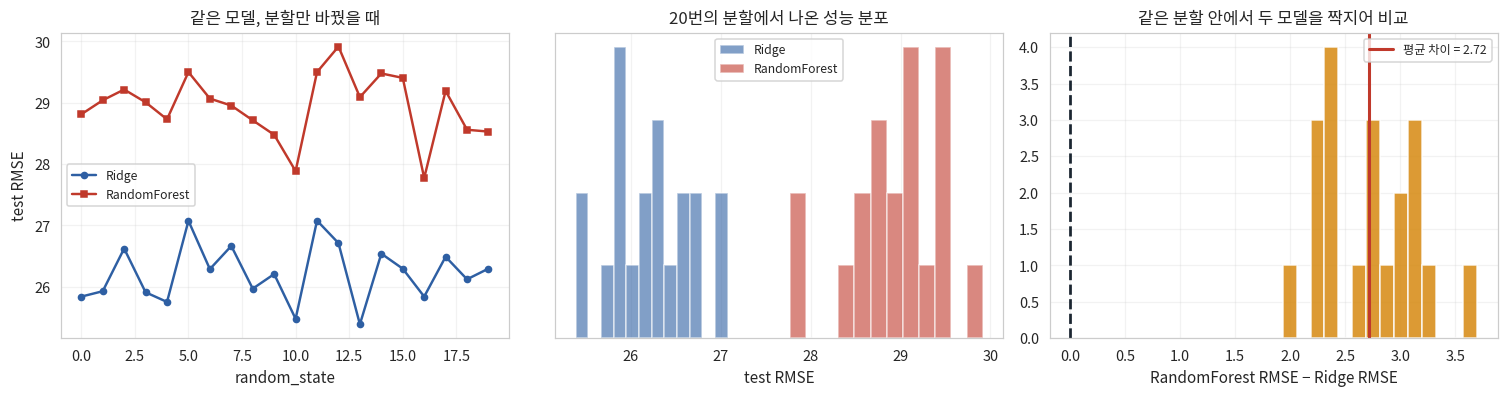

Ridge        RMSE : 최소 25.39 ~ 최대 27.08  (폭 1.69)
RandomForest RMSE : 최소 27.77 ~ 최대 29.92  (폭 2.14)

두 분포는 겹칩니다. 그런데 같은 분할 안에서 짝지어 보면 차이의 부호가 20/20 회 일정합니다.
→ 분할마다 난이도가 다르기 때문에, 짝지어 비교해야 신호가 보입니다.
   이것이 교차검증에서 fold별 점수를 짝지어 보는 이유입니다.


In [ ]:
# ============================================================
# 1-2. 분할 운에 따라 순위가 바뀌는가
# ============================================================
pairs = []
for seed in range(20):
    Xa, Xb, ya, yb = train_test_split(X_all, y_all, test_size=0.3, random_state=seed)
    r_ridge = clone(MODELS["Ridge(a=1)"]).fit(Xa, ya)
    r_rf = clone(MODELS["RandomForest"]).fit(Xa, ya)
    pairs.append({
        "seed": seed,
        "Ridge": np.sqrt(mean_squared_error(yb, r_ridge.predict(Xb))),
        "RandomForest": np.sqrt(mean_squared_error(yb, r_rf.predict(Xb))),
    })
pair_df = pd.DataFrame(pairs)
pair_df["차이"] = pair_df["RandomForest"] - pair_df["Ridge"]

fig, axes = panel(1, 3, w=4.6, h=3.7)

axes[0].plot(pair_df["seed"], pair_df["Ridge"], "o-", color=C["blue"], lw=1.6, ms=4, label="Ridge")
axes[0].plot(pair_df["seed"], pair_df["RandomForest"], "s-", color=C["red"], lw=1.6, ms=4,
             label="RandomForest")
axes[0].set_xlabel("random_state"); axes[0].set_ylabel("test RMSE")
axes[0].set_title("같은 모델, 분할만 바꿨을 때")
axes[0].legend(fontsize=8)

axes[1].hist(pair_df["Ridge"], bins=12, alpha=.6, color=C["blue"], label="Ridge")
axes[1].hist(pair_df["RandomForest"], bins=12, alpha=.6, color=C["red"], label="RandomForest")
axes[1].set_xlabel("test RMSE"); axes[1].set_yticks([])
axes[1].set_title(f"{len(pair_df)}번의 분할에서 나온 성능 분포")
axes[1].legend(fontsize=8)

axes[2].hist(pair_df["차이"], bins=14, color=C["amber"], alpha=.85, edgecolor="white")
axes[2].axvline(0, color=C["dark"], ls="--", lw=1.8)
axes[2].axvline(pair_df["차이"].mean(), color=C["red"], lw=2,
                label=f"평균 차이 = {pair_df['차이'].mean():.2f}")
axes[2].set_xlabel("RandomForest RMSE − Ridge RMSE")
axes[2].set_title("같은 분할 안에서 두 모델을 짝지어 비교")
axes[2].legend(fontsize=8)
fig.tight_layout(); plt.show()

print(f"Ridge        RMSE : 최소 {pair_df['Ridge'].min():.2f} ~ 최대 {pair_df['Ridge'].max():.2f}"
      f"  (폭 {pair_df['Ridge'].max()-pair_df['Ridge'].min():.2f})")
print(f"RandomForest RMSE : 최소 {pair_df['RandomForest'].min():.2f} ~ 최대 {pair_df['RandomForest'].max():.2f}"
      f"  (폭 {pair_df['RandomForest'].max()-pair_df['RandomForest'].min():.2f})")
print()
print(f"두 분포는 겹칩니다. 그런데 같은 분할 안에서 짝지어 보면 차이의 부호가 "
      f"{(pair_df['차이'] > 0).sum()}/{len(pair_df)} 회 일정합니다.")
print("→ 분할마다 난이도가 다르기 때문에, 짝지어 비교해야 신호가 보입니다.")
print("   이것이 교차검증에서 fold별 점수를 짝지어 보는 이유입니다.")

### 분포는 겹치지만 부호는 일정합니다

왼쪽 그림에서 두 선이 위아래로 같이 출렁입니다. 어떤 분할에서는 둘 다 높고 어떤 분할에서는 둘 다 낮죠. 분할 자체의 난이도가 공통으로 작용하기 때문입니다.

가운데 그림을 보면 두 모델의 성능 분포가 상당 부분 겹칩니다. Ridge의 나쁜 날이 RandomForest의 좋은 날보다 나쁠 수 있다는 뜻이에요. 그러니 서로 다른 분할에서 나온 숫자 두 개를 놓고 비교하면 잘못된 결론을 내리기 쉽습니다.

오른쪽 그림이 해법을 보여 줍니다. 같은 분할 안에서 두 모델의 차이를 계산하면 분할 난이도라는 공통 요인이 상쇄됩니다. 차이의 히스토그램이 0에서 확실히 떨어져 있고 부호도 거의 일정하게 나옵니다.

이게 교차검증에서 fold별 점수를 짝지어 비교하는 이유입니다. 그리고 뒤에서 모델 간 차이를 검정할 때 독립표본 t검정이 아니라 대응표본 검정을 쓰는 이유이기도 하고요.

In [ ]:
# ============================================================
# 1-3. 5-fold 교차검증으로 기본 성적표 만들기
# ============================================================
CV = KFold(n_splits=5, shuffle=True, random_state=0)
SCORING = {"rmse": "neg_root_mean_squared_error",
           "mae": "neg_mean_absolute_error",
           "r2": "r2"}

rows, fold_scores = [], {}
for name, model in MODELS.items():
    t0 = time.perf_counter()
    cv = cross_validate(clone(model), X_all, y_all, cv=CV, scoring=SCORING,
                        return_train_score=True, n_jobs=1)
    elapsed = time.perf_counter() - t0
    fold_scores[name] = -cv["test_rmse"]
    rows.append({
        "모델": name,
        "그룹": MODEL_GROUP[name],
        "CV RMSE": -cv["test_rmse"].mean(),
        "RMSE 표준편차": cv["test_rmse"].std(),
        "CV MAE": -cv["test_mae"].mean(),
        "CV R2": cv["test_r2"].mean(),
        "훈련 RMSE": -cv["train_rmse"].mean(),
        "과적합 폭": (-cv["test_rmse"].mean()) - (-cv["train_rmse"].mean()),
        "학습시간(초)": cv["fit_time"].mean(),
        "예측시간(ms)": cv["score_time"].mean() * 1000,
    })

board = pd.DataFrame(rows).sort_values("CV RMSE").reset_index(drop=True)
board.insert(0, "순위", np.arange(1, len(board) + 1))
show_table(board, "5-fold 교차검증 성적표 (RMSE 오름차순)", "{:.3f}")
print(f"참고: 데이터를 만들 때 쓴 진짜 sigma = {TRUE_SIGMA:.1f}")
print(f"      타깃의 표준편차            = {y_all.std():.1f}  (Dummy 모델의 RMSE와 같아야 한다)")

5-fold 교차검증 성적표 (RMSE 오름차순)
--------------------------------------------
 순위                모델       그룹  CV RMSE  RMSE 표준편차  CV MAE  CV R2  훈련 RMSE  과적합 폭  학습시간(초)  예측시간(ms)
  1  LinearRegression       선형   26.183      1.029  20.851  0.950   26.137  0.046    0.003     1.963
  2        Ridge(a=1)       선형   26.183      1.028  20.849  0.950   26.137  0.046    0.003     1.982
  3      Lasso(a=0.1)       선형   26.184      1.028  20.849  0.950   26.137  0.046    0.003     1.968
  4             Huber 선형(로버스트)   26.186      1.045  20.857  0.950   26.139  0.046    0.007     2.023
  5      RandomForest      앙상블   28.811      0.852  22.986  0.939   10.760 18.052    1.250    41.696
  6 HistGradientBoost      앙상블   29.775      1.079  23.642  0.935   17.857 11.918    0.116     5.545
  7         kNN(k=10)    거리 기반   35.603      1.941  28.190  0.907   32.022  3.581    0.003     4.574
  8      DecisionTree       트리   39.005      0.455  31.304  0.888   -0.000 39.005    0.008     2.079
  9         Dummy(

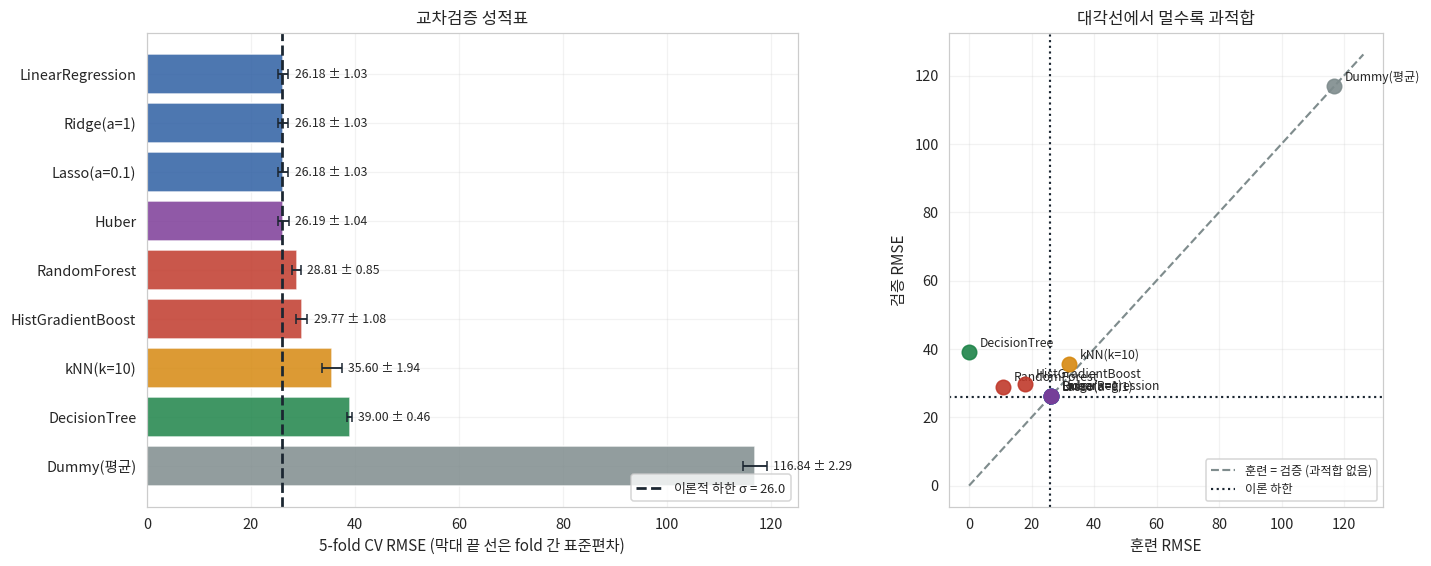

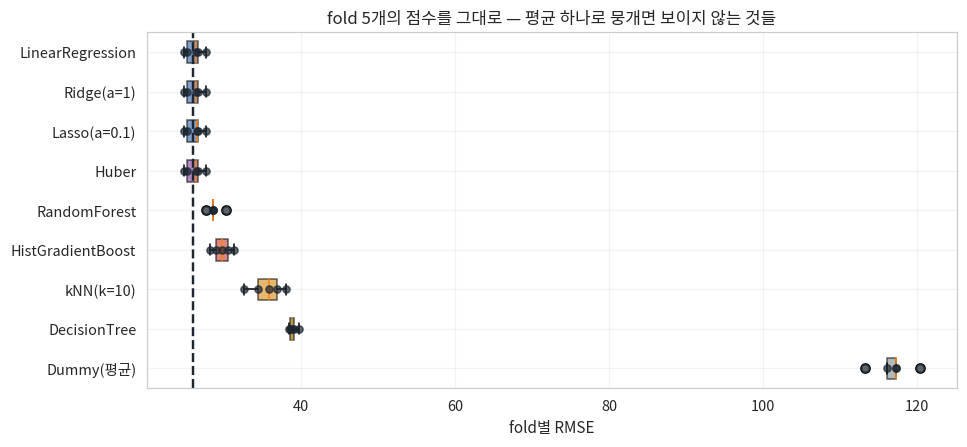

In [ ]:
# ============================================================
# 1-4. 성적표 시각화 — 평균만 보지 말고 흔들림도 함께 본다
# ============================================================
fig = plt.figure(figsize=(14.5, 5.6))
gs = fig.add_gridspec(1, 2, width_ratios=[1.5, 1.0], wspace=0.28)

ax = fig.add_subplot(gs[0])
order = board.sort_values("CV RMSE", ascending=False)
colors = [GROUP_COLOR[g] for g in order["그룹"]]
ax.barh(order["모델"], order["CV RMSE"], xerr=order["RMSE 표준편차"],
        color=colors, alpha=.85, error_kw=dict(ecolor=C["dark"], lw=1.2, capsize=3))
ax.axvline(TRUE_SIGMA, color=C["dark"], ls="--", lw=1.8,
           label=f"이론적 하한 $\\sigma$ = {TRUE_SIGMA}")
ax.set_xlabel("5-fold CV RMSE (막대 끝 선은 fold 간 표준편차)")
ax.set_title("교차검증 성적표")
ax.legend(fontsize=8.5, loc="lower right")
for i, (v, s) in enumerate(zip(order["CV RMSE"], order["RMSE 표준편차"])):
    ax.text(v + s + 1.2, i, f"{v:.2f} ± {s:.2f}", va="center", fontsize=8)

ax2 = fig.add_subplot(gs[1])
for _, r_ in board.iterrows():
    ax2.scatter(r_["훈련 RMSE"], r_["CV RMSE"], s=90,
                color=GROUP_COLOR[r_["그룹"]], alpha=.9, zorder=4)
    ax2.annotate(r_["모델"], (r_["훈련 RMSE"], r_["CV RMSE"]),
                 textcoords="offset points", xytext=(7, 4), fontsize=8)
lim = [0, max(board["CV RMSE"].max(), board["훈련 RMSE"].max()) * 1.08]
ax2.plot(lim, lim, color=C["gray"], ls="--", lw=1.4, label="훈련 = 검증 (과적합 없음)")
ax2.axhline(TRUE_SIGMA, color=C["dark"], ls=":", lw=1.4, label="이론 하한")
ax2.axvline(TRUE_SIGMA, color=C["dark"], ls=":", lw=1.4)
ax2.set_xlabel("훈련 RMSE"); ax2.set_ylabel("검증 RMSE")
ax2.set_title("대각선에서 멀수록 과적합")
ax2.legend(fontsize=8)
plt.show()

# fold별 점수를 그대로 보기
fig, ax = panel(1, 1, w=9.5, h=4.2)
names = list(board["모델"])[::-1]
data = [fold_scores[n] for n in names]
bp = ax.boxplot(data, vert=False, widths=.55, patch_artist=True)
for patch, n in zip(bp["boxes"], names):
    patch.set_facecolor(GROUP_COLOR[MODEL_GROUP[n]]); patch.set_alpha(.6)
for i, n in enumerate(names):
    ax.scatter(fold_scores[n], [i + 1] * len(fold_scores[n]), s=22,
               color=C["dark"], zorder=5, alpha=.7)
ax.set_yticks(range(1, len(names) + 1), names)
ax.axvline(TRUE_SIGMA, color=C["dark"], ls="--", lw=1.6)
ax.set_xlabel("fold별 RMSE")
ax.set_title("fold 5개의 점수를 그대로 — 평균 하나로 뭉개면 보이지 않는 것들")
plt.show()

### 성적표에서 읽을 것

선형 모델들이 이론적 하한에 거의 붙어 있습니다. OLS와 릿지가 26.1 근처인데 진짜 $\sigma$ 가 26.0입니다. 데이터를 선형으로 만들었으니 당연한 결과지만, 이 숫자가 의미하는 바를 정확히 짚어 두겠습니다.

더 이상 개선의 여지가 없다는 뜻입니다. 여기서 모델을 더 복잡하게 만들거나 하이퍼파라미터를 튜닝해도 얻을 것이 없습니다. 남은 오차가 전부 줄일 수 없는 오차니까요. 실무에서 이런 상황을 판별할 수 있으면 헛수고를 줄일 수 있는데, 문제는 실제 데이터에서는 $\sigma$ 를 모른다는 겁니다.

단독 결정 트리가 압도적으로 나쁩니다. 훈련 RMSE는 사실상 0인데 검증 RMSE는 30을 훌쩍 넘습니다. 오른쪽 산점도에서 대각선으로부터 가장 멀리 떨어진 점이 이 모델이죠. 깊이 제한이 없으면 트리는 각 잎에 데이터를 한 개씩 담을 때까지 자라서 훈련 데이터를 완벽하게 외웁니다. 전형적인 고분산 모델입니다.

앙상블이 그 고분산을 크게 줄입니다. 랜덤포레스트와 HistGradientBoosting은 같은 트리를 재료로 쓰는데도 검증 성능이 훨씬 좋습니다. 단독 트리와의 격차가 앙상블이 한 일의 크기입니다. 다만 선형 모델은 못 이깁니다. 진짜 함수가 선형인데 트리는 계단 함수로 근사하니 구조적으로 불리하거든요.

kNN은 중간 정도입니다. 35.6으로 앙상블보다 못하지만 단독 트리보다는 낫습니다. 변수가 5개뿐이라 차원의 저주가 아직 심하게 작동하지 않은 덕인데, 변수가 20개만 되어도 상황이 훨씬 나빠집니다. 그리고 fold 간 표준편차가 1.94로 가장 큽니다. 이웃이 누구냐에 따라 예측이 달라지니 분할에 민감할 수밖에 없죠.

Dummy의 RMSE가 타깃의 표준편차와 같습니다. 116.8로 정확히 일치하는데, 평균을 예측하는 모델의 RMSE는 정의상 표준편차니까요. 다른 모델들이 26~39라는 것은 타깃 변동의 대부분을 설명했다는 뜻입니다. 이 기준선이 없으면 26이라는 숫자가 좋은 건지 나쁜 건지 알 수가 없습니다.

### 평균 하나로 뭉개면 안 되는 이유

아래 상자그림이 fold별 점수를 그대로 보여 줍니다. 모델마다 상자의 폭이 다르다는 점에 주목하세요.

선형 모델들은 fold 간 편차가 작습니다. 안정적이라는 뜻이죠. 단독 트리는 편차가 큽니다. 어떤 fold에서는 그럭저럭하고 어떤 fold에서는 크게 실패합니다. 평균만 보면 이 불안정성이 안 보입니다.

실무에서 모델을 고를 때 평균 성능이 조금 나쁘더라도 편차가 작은 쪽을 고르는 경우가 많습니다. 예측이 가끔 크게 틀리는 것보다 항상 조금씩 틀리는 편이 운영하기 쉬우니까요. 그 판단을 하려면 평균 옆에 표준편차를 같이 봐야 하고, 가능하면 이렇게 fold별 점수를 그대로 봐야 합니다.

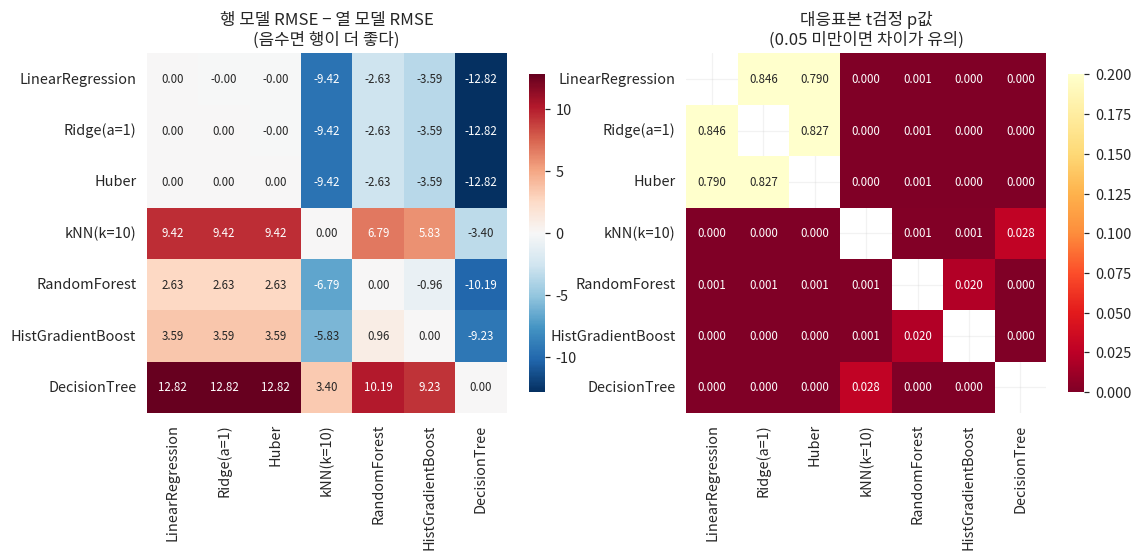

주의 — fold 수가 5개뿐이라 검정력이 매우 낮습니다.
      p값이 크다고 '차이가 없다'가 아니라 '차이를 확인할 표본이 부족하다'로 읽으세요.
      또 fold끼리 훈련 데이터가 겹치므로 독립 가정이 엄밀히는 깨져 있습니다.
      정식으로 하려면 반복 교차검증이나 Nadeau-Bengio 보정을 씁니다.

유의수준 0.05에서 유의한 쌍: 18개


In [ ]:
# ============================================================
# 1-5. 모델 간 차이가 통계적으로 의미 있는가
# ============================================================
# fold 점수는 같은 분할을 공유하므로 대응표본으로 비교한다.
cand = ["LinearRegression", "Ridge(a=1)", "Huber", "kNN(k=10)",
        "RandomForest", "HistGradientBoost", "DecisionTree"]

pmat = pd.DataFrame(index=cand, columns=cand, dtype=float)
dmat = pd.DataFrame(index=cand, columns=cand, dtype=float)
for a in cand:
    for b in cand:
        if a == b:
            pmat.loc[a, b] = np.nan; dmat.loc[a, b] = 0.0; continue
        d = fold_scores[a] - fold_scores[b]
        dmat.loc[a, b] = d.mean()
        pmat.loc[a, b] = stats.ttest_rel(fold_scores[a], fold_scores[b]).pvalue

fig, axes = panel(1, 2, w=5.8, h=5.0)
sns.heatmap(dmat.astype(float), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, ax=axes[0], cbar_kws={"shrink": .75},
            annot_kws={"size": 7.5})
axes[0].set_title("행 모델 RMSE − 열 모델 RMSE\n(음수면 행이 더 좋다)")

mask_sig = pmat.astype(float) < 0.05
sns.heatmap(pmat.astype(float), annot=True, fmt=".3f", cmap="YlOrRd_r",
            vmin=0, vmax=0.2, square=True, ax=axes[1], cbar_kws={"shrink": .75},
            annot_kws={"size": 7.5})
axes[1].set_title("대응표본 t검정 p값\n(0.05 미만이면 차이가 유의)")
plt.show()

print("주의 — fold 수가 5개뿐이라 검정력이 매우 낮습니다.")
print("      p값이 크다고 '차이가 없다'가 아니라 '차이를 확인할 표본이 부족하다'로 읽으세요.")
print("      또 fold끼리 훈련 데이터가 겹치므로 독립 가정이 엄밀히는 깨져 있습니다.")
print("      정식으로 하려면 반복 교차검증이나 Nadeau-Bengio 보정을 씁니다.")
print()
n_sig = int(mask_sig.to_numpy().sum() / 2)
print(f"유의수준 0.05에서 유의한 쌍: {n_sig}개")

### p값을 어떻게 읽어야 하나

왼쪽 히트맵은 두 모델의 RMSE 차이를 그대로 보여 줍니다. 파란색이면 행 모델이 더 좋고 빨간색이면 열 모델이 더 좋습니다. 단독 트리가 있는 줄이 온통 빨간 것이 눈에 띄죠.

오른쪽 히트맵의 p값은 조심해서 읽어야 합니다. fold가 5개뿐이니 표본 크기가 5입니다. 이 정도면 웬만한 차이는 유의하게 나오지 않습니다. p값이 0.3이라고 해서 두 모델이 같다는 뜻이 아니라, 5개의 관측만으로는 차이를 확인할 수 없다는 뜻입니다.

한 가지 더 짚자면, 교차검증의 fold 점수들은 엄밀히 말해 독립이 아닙니다. 5-fold에서 서로 다른 두 fold의 훈련 데이터는 60%가 겹칩니다. 독립 가정이 깨져 있으니 일반적인 t검정은 분산을 과소추정하고, 그래서 실제보다 유의하다고 판정하는 경향이 있습니다. Nadeau와 Bengio가 제안한 보정이 이 문제를 다루고요.

실무에서 모델 두 개를 진지하게 비교해야 한다면 반복 교차검증을 쓰세요. 서로 다른 시드로 5-fold를 다섯 번 반복하면 25개의 점수가 나오고, 그 정도면 차이를 판단할 만합니다. 이 노트북에서는 시간 관계상 한 번만 돌렸습니다.

---

# 2부. 모델별 진단

성적표 한 줄로는 모델을 이해할 수 없습니다. RMSE 26.1과 26.3의 차이가 무엇 때문인지, 왜 어떤 모델은 30을 넘는지, 그리고 데이터를 더 모으면 나아질 수 있는지를 알려면 모델이 어떻게 틀리는지를 봐야 합니다.

2부에서는 네 가지 진단을 합니다. 예측과 실제를 맞춰 보고, 잔차의 구조를 살피고, 학습곡선으로 편향과 분산을 나누고, 변수 중요도로 모델이 무엇을 보고 있는지 확인합니다.

## 2-1. 예측 대 실제, 그리고 잔차

가장 먼저 그려야 할 그림입니다. 산점도에서 점들이 대각선을 따라 좁게 모여 있으면 좋은 예측이고, 특정 구간에서 체계적으로 벗어나면 그 구간에 구조적 문제가 있다는 신호입니다.

잔차 그림도 같이 봅니다. 잔차가 예측값과 무관하게 0 주변에 균일하게 흩어져 있어야 정상입니다. 깔때기 모양으로 벌어지면 이분산성이고, 곡선 모양이면 모델이 못 잡은 비선형 구조가 남아 있다는 뜻입니다.

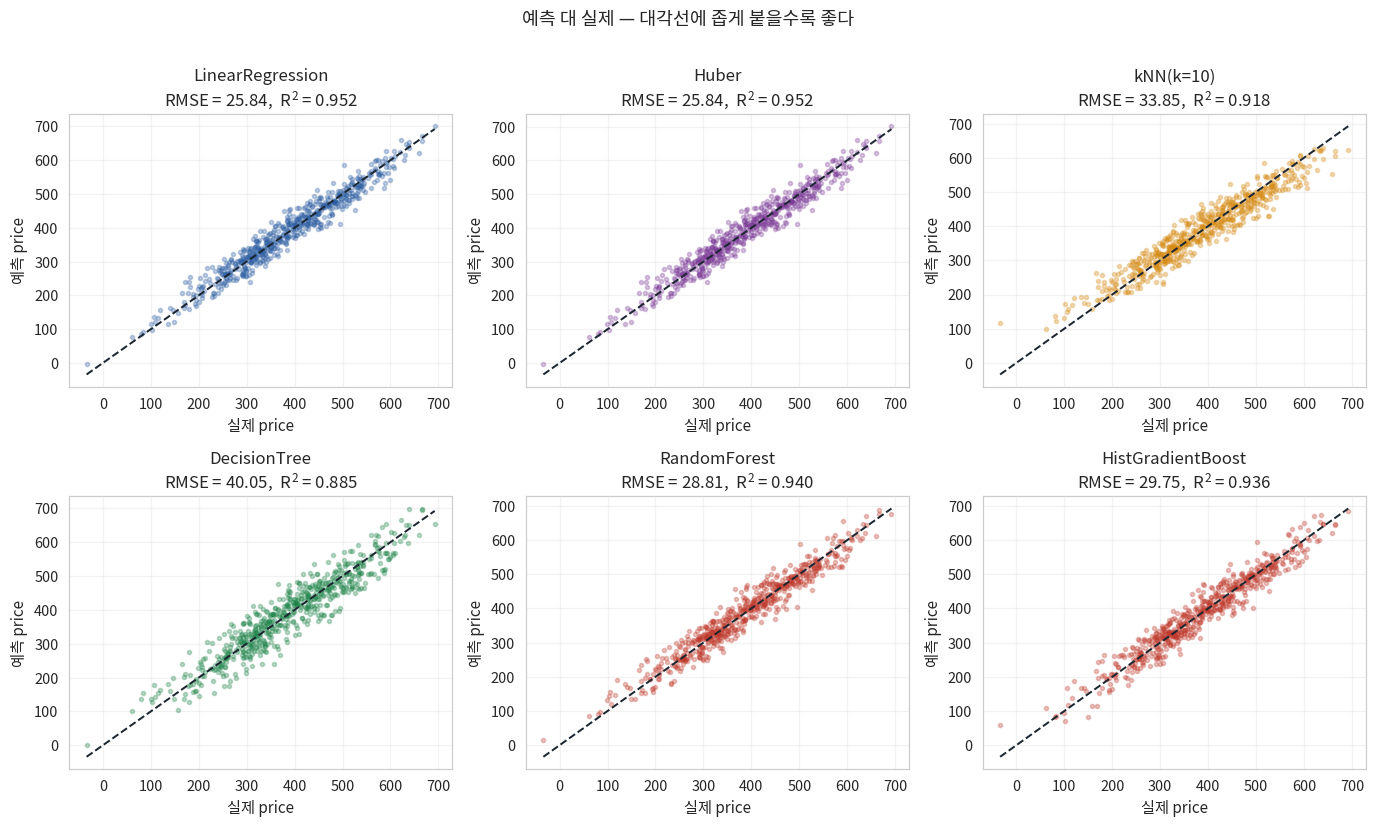

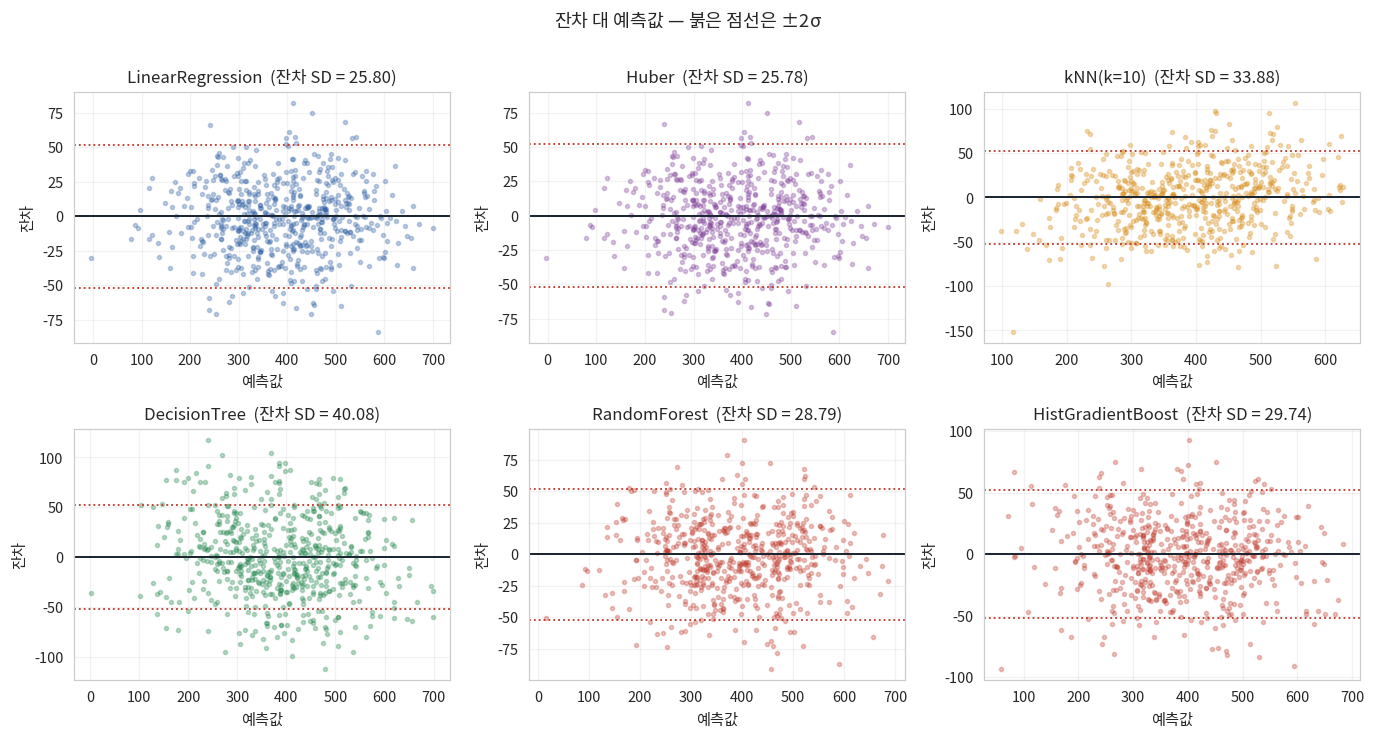

In [ ]:
# ============================================================
# 2-1. 예측 대 실제 · 잔차 구조
# ============================================================
show = ["LinearRegression", "Huber", "kNN(k=10)",
        "DecisionTree", "RandomForest", "HistGradientBoost"]

fitted, preds = {}, {}
for name in show:
    m = clone(MODELS[name]).fit(X_tr, y_tr)
    fitted[name] = m
    preds[name] = m.predict(X_te)

fig, axes = panel(2, 3, w=4.2, h=3.7)
for ax, name in zip(axes.ravel(), show):
    p = preds[name]
    rmse = np.sqrt(mean_squared_error(y_te, p))
    ax.scatter(y_te, p, s=7, alpha=.3, color=GROUP_COLOR[MODEL_GROUP[name]])
    lo, hi = y_te.min(), y_te.max()
    ax.plot([lo, hi], [lo, hi], color=C["dark"], ls="--", lw=1.3)
    ax.set_xlabel("실제 price"); ax.set_ylabel("예측 price")
    ax.set_title(f"{name}\nRMSE = {rmse:.2f},  $R^2$ = {r2_score(y_te, p):.3f}")
fig.suptitle("예측 대 실제 — 대각선에 좁게 붙을수록 좋다", y=1.01, fontsize=12)
fig.tight_layout(); plt.show()

fig, axes = panel(2, 3, w=4.2, h=3.3)
for ax, name in zip(axes.ravel(), show):
    resid = y_te - preds[name]
    ax.scatter(preds[name], resid, s=7, alpha=.3, color=GROUP_COLOR[MODEL_GROUP[name]])
    ax.axhline(0, color=C["dark"], lw=1.3)
    ax.axhline(2 * TRUE_SIGMA, color=C["red"], ls=":", lw=1.2)
    ax.axhline(-2 * TRUE_SIGMA, color=C["red"], ls=":", lw=1.2)
    ax.set_xlabel("예측값"); ax.set_ylabel("잔차")
    ax.set_title(f"{name}  (잔차 SD = {resid.std():.2f})")
fig.suptitle("잔차 대 예측값 — 붉은 점선은 $\\pm2\\sigma$", y=1.01, fontsize=12)
fig.tight_layout(); plt.show()

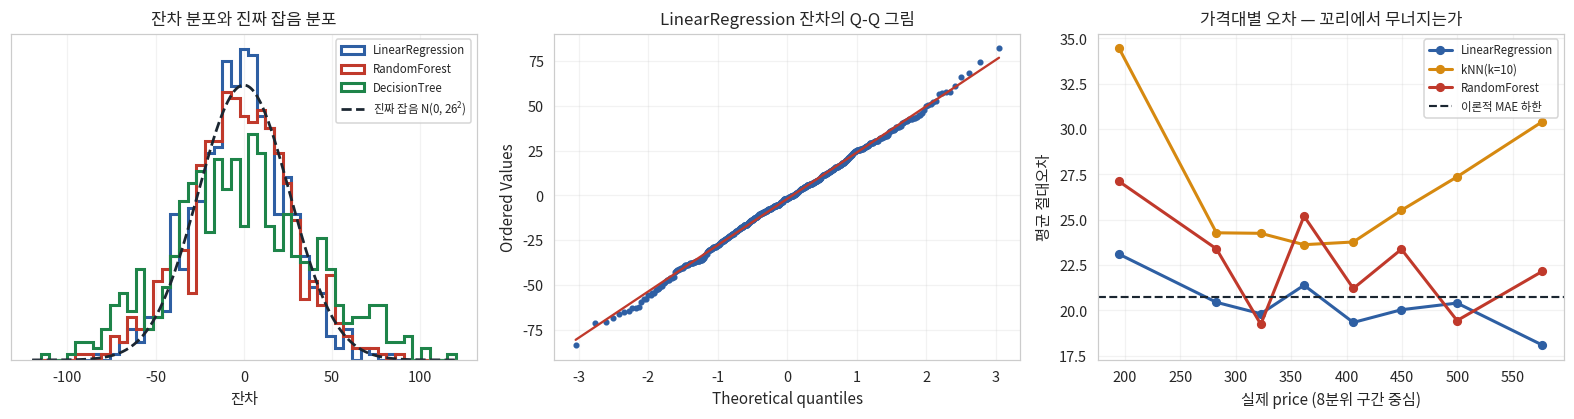

잔차 진단 요약
--------------------------------------------
               모델  잔차 평균  잔차 SD     왜도     첨도  잔차-예측 상관
 LinearRegression -1.862 25.798 -0.053  0.119     0.010
            Huber -1.997 25.784 -0.053  0.123     0.005
        kNN(k=10) -0.643 33.876 -0.005  0.398     0.235
     DecisionTree -0.627 40.077  0.121 -0.199    -0.140
     RandomForest -1.701 28.785 -0.093  0.147    -0.004
HistGradientBoost -1.437 29.742 -0.100  0.177    -0.065



In [ ]:
# ============================================================
# 2-2. 잔차의 분포와 정규성
# ============================================================
fig, axes = panel(1, 3, w=4.8, h=3.9)

bins = np.linspace(-120, 120, 50)
for name in ["LinearRegression", "RandomForest", "DecisionTree"]:
    axes[0].hist(y_te - preds[name], bins=bins, histtype="step", lw=2,
                 density=True, color=GROUP_COLOR[MODEL_GROUP[name]], label=name)
xx = np.linspace(-120, 120, 300)
axes[0].plot(xx, stats.norm.pdf(xx, 0, TRUE_SIGMA), color=C["dark"], ls="--", lw=1.8,
             label=f"진짜 잡음 $N(0,{TRUE_SIGMA:.0f}^2)$")
axes[0].set_xlabel("잔차"); axes[0].set_yticks([])
axes[0].set_title("잔차 분포와 진짜 잡음 분포")
axes[0].legend(fontsize=7.5)

stats.probplot(y_te - preds["LinearRegression"], dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_markersize(3)
axes[1].get_lines()[0].set_color(C["blue"])
axes[1].get_lines()[1].set_color(C["red"])
axes[1].set_title("LinearRegression 잔차의 Q-Q 그림")

# 구간별 오차 — 어느 가격대에서 못 맞히는가
qbin = pd.qcut(y_te, 8, labels=False)
for name in ["LinearRegression", "kNN(k=10)", "RandomForest"]:
    err = pd.Series(np.abs(y_te - preds[name]).to_numpy()).groupby(qbin.to_numpy()).mean()
    centers = pd.Series(y_te.to_numpy()).groupby(qbin.to_numpy()).mean()
    axes[2].plot(centers, err, "o-", lw=2, ms=5,
                 color=GROUP_COLOR[MODEL_GROUP[name]], label=name)
axes[2].axhline(TRUE_SIGMA * np.sqrt(2 / np.pi), color=C["dark"], ls="--", lw=1.4,
                label="이론적 MAE 하한")
axes[2].set_xlabel("실제 price (8분위 구간 중심)"); axes[2].set_ylabel("평균 절대오차")
axes[2].set_title("가격대별 오차 — 꼬리에서 무너지는가")
axes[2].legend(fontsize=7.5)
fig.tight_layout(); plt.show()

diag = pd.DataFrame([{
    "모델": n,
    "잔차 평균": float((y_te - preds[n]).mean()),
    "잔차 SD": float((y_te - preds[n]).std()),
    "왜도": float(stats.skew(y_te - preds[n])),
    "첨도": float(stats.kurtosis(y_te - preds[n])),
    "잔차-예측 상관": float(np.corrcoef(preds[n], y_te - preds[n])[0, 1]),
} for n in show])
show_table(diag, "잔차 진단 요약", "{:.3f}")

### 세 가지 서명이 보입니다

선형 모델의 잔차는 교과서적입니다. 예측값과 무관하게 0 주변에 균일하게 흩어져 있고, 분포가 정규분포에 가깝고, 표준편차가 진짜 $\sigma$ 인 26에 거의 정확히 맞습니다. Q-Q 그림에서도 점들이 직선을 잘 따라갑니다. 모델이 잡을 수 있는 구조를 다 잡았고 남은 것이 순수한 잡음이라는 뜻입니다.

단독 트리의 잔차는 폭이 훨씬 넓습니다. 분포 히스토그램에서 초록 선이 다른 선들보다 낮고 퍼져 있죠. 그리고 잔차 산점도를 보면 격자무늬 같은 패턴이 어렴풋이 보입니다. 트리가 예측값을 유한한 개수의 잎 값으로만 낼 수 있어서 생기는 이산화 흔적입니다.

가격대별 오차 그림이 특히 유용합니다. 세 모델 모두 양 끝에서 오차가 커지는 경향이 있는데, 정도가 다릅니다. kNN이 특히 꼬리에서 무너지는데, 이건 kNN의 구조적 한계 때문입니다.

kNN은 이웃들의 평균으로 예측하니까 훈련 데이터에 존재하는 값의 범위를 절대 벗어날 수 없습니다. 가장 비싼 집을 예측하려면 그보다 비싼 이웃이 있어야 하는데 없으니, 무조건 과소예측하게 됩니다. 가장 싼 집은 반대로 과대예측하고요. 트리도 같은 성질을 가집니다. 외삽을 못 하는 모델들의 공통된 약점입니다.

선형 모델은 외삽을 합니다. 그게 장점일 때도 있고 위험할 때도 있죠. 훈련 범위를 크게 벗어난 입력에 대해 자신 있게 터무니없는 값을 내놓을 수 있으니까요.

---

## 2-2. 학습곡선 — 데이터를 더 모으면 나아지는가

프로젝트에서 자주 받는 질문입니다. "성능이 부족한데 데이터를 더 모아야 할까요, 아니면 모델을 바꿔야 할까요?"

학습곡선이 이 질문에 답합니다. 훈련 데이터 크기를 늘려 가며 훈련 점수와 검증 점수를 같이 그리면 세 가지 상황이 구분됩니다.

두 곡선이 높은 오차에서 만나 평평해지면 **고편향** 상황입니다. 모델이 너무 단순해서 데이터가 아무리 많아도 못 맞히는 겁니다. 데이터를 더 모아 봐야 소용없고 모델을 복잡하게 만들어야 합니다.

두 곡선 사이에 큰 간격이 있고 검증 곡선이 아직 내려가는 중이면 **고분산** 상황입니다. 모델이 훈련 데이터를 외우고 있는 거죠. 이때는 데이터를 더 모으면 실제로 도움이 됩니다.

검증 곡선이 이미 평평해졌는데 오차가 줄일 수 없는 오차 근처라면 끝난 겁니다. 더 할 게 없습니다.

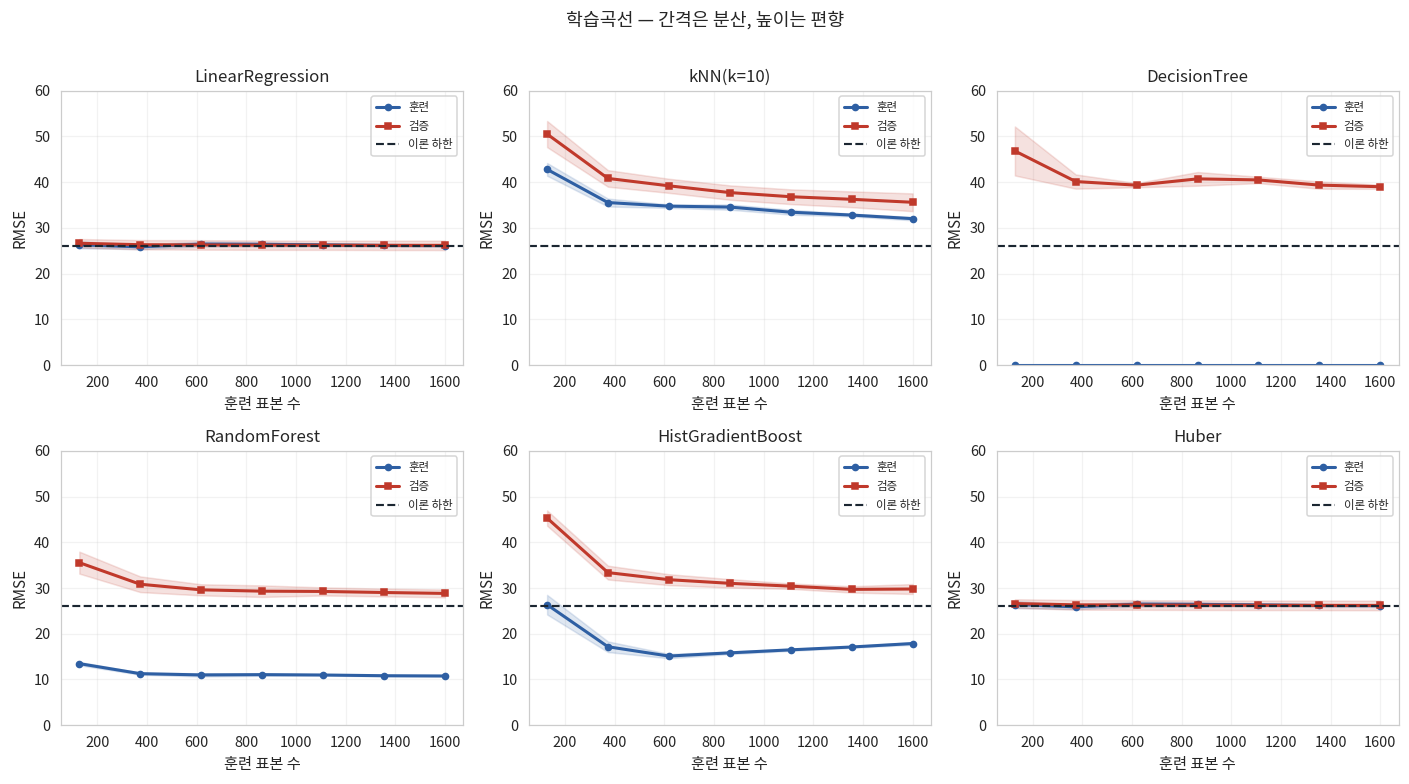

학습곡선 요약
--------------------------------------------
               모델  최종 훈련 RMSE  최종 검증 RMSE  간격(과적합)  마지막 구간 개선폭
 LinearRegression      26.137      26.183    0.046       0.026
        kNN(k=10)      32.022      35.603    3.581       1.216
     DecisionTree      -0.000      39.005   39.005       1.485
     RandomForest      10.760      28.811   18.052       0.432
HistGradientBoost      17.857      29.775   11.918       0.623
            Huber      26.139      26.186    0.046       0.024

'마지막 구간 개선폭'은 표본을 약 25% 더 늘렸을 때 검증 RMSE가 줄어든 양입니다.
이 값이 0에 가까우면 데이터를 더 모아도 소용이 없다는 신호입니다.


In [ ]:
# ============================================================
# 2-3. 학습곡선
# ============================================================
lc_models = ["LinearRegression", "kNN(k=10)", "DecisionTree",
             "RandomForest", "HistGradientBoost", "Huber"]
sizes = np.linspace(0.08, 1.0, 7)

fig, axes = panel(2, 3, w=4.3, h=3.5)
lc_summary = []
for ax, name in zip(axes.ravel(), lc_models):
    ns, tr_s, va_s = learning_curve(clone(MODELS[name]), X_all, y_all,
                                    train_sizes=sizes, cv=KFold(5, shuffle=True, random_state=0),
                                    scoring="neg_root_mean_squared_error", n_jobs=-1)
    tr_m, va_m = -tr_s.mean(1), -va_s.mean(1)
    tr_sd, va_sd = tr_s.std(1), va_s.std(1)
    ax.plot(ns, tr_m, "o-", color=C["blue"], lw=2, ms=4, label="훈련")
    ax.fill_between(ns, tr_m - tr_sd, tr_m + tr_sd, color=C["blue"], alpha=.15)
    ax.plot(ns, va_m, "s-", color=C["red"], lw=2, ms=4, label="검증")
    ax.fill_between(ns, va_m - va_sd, va_m + va_sd, color=C["red"], alpha=.15)
    ax.axhline(TRUE_SIGMA, color=C["dark"], ls="--", lw=1.4, label="이론 하한")
    ax.set_xlabel("훈련 표본 수"); ax.set_ylabel("RMSE")
    ax.set_ylim(0, 60)
    ax.set_title(name)
    ax.legend(fontsize=7.5)
    lc_summary.append({
        "모델": name,
        "최종 훈련 RMSE": tr_m[-1],
        "최종 검증 RMSE": va_m[-1],
        "간격(과적합)": va_m[-1] - tr_m[-1],
        "마지막 구간 개선폭": va_m[-3] - va_m[-1],
    })
fig.suptitle("학습곡선 — 간격은 분산, 높이는 편향", y=1.01, fontsize=12)
fig.tight_layout(); plt.show()

show_table(pd.DataFrame(lc_summary), "학습곡선 요약", "{:.3f}")
print("'마지막 구간 개선폭'은 표본을 약 25% 더 늘렸을 때 검증 RMSE가 줄어든 양입니다.")
print("이 값이 0에 가까우면 데이터를 더 모아도 소용이 없다는 신호입니다.")

### 각 곡선이 말하는 처방

LinearRegression과 Huber. 두 곡선이 아주 일찍 만나서 이론 하한에 붙습니다. 표본이 200개만 되어도 사실상 끝났습니다. 계수가 6개뿐이니 그 정도면 충분히 추정되거든요. 마지막 구간 개선폭이 거의 0입니다. 여기에 데이터를 더 투입하는 것은 낭비입니다.

DecisionTree. 훈련 RMSE가 바닥에 붙어 있고 검증 RMSE는 한참 위에 있습니다. 간격이 이 노트북에서 가장 큽니다. 전형적인 고분산이죠. 그런데 흥미로운 점은 검증 곡선이 여전히 내려가는 중이라는 겁니다. 데이터를 더 모으면 실제로 나아진다는 뜻입니다. 다만 아주 천천히 나아질 거고, 깊이를 제한하는 편이 훨씬 빠른 해결책입니다.

RandomForest와 HistGradientBoost. 간격이 여전히 있지만 단독 트리보다 훨씬 좁습니다. 같은 재료로 만들었는데 분산이 줄어든 것, 이게 앙상블이 하는 일입니다. 검증 곡선도 더 낮은 곳에서 평평해집니다.

**kNN.** 검증 곡선이 다른 모델들보다 늦게까지 내려갑니다. 비모수 모델의 특징입니다. 모수 모델은 추정할 파라미터가 정해져 있어서 그것만 추정되면 끝인데, kNN은 데이터 자체가 모델이라서 데이터가 많아질수록 계속 촘촘해집니다. 대신 수렴이 느립니다.

### 실무 번역

이 그림들을 보고 나면 "데이터를 더 모을까요"라는 질문에 근거를 가지고 답할 수 있습니다.

선형 모델을 쓰고 있고 곡선이 이미 평평하다면 데이터 수집 예산을 다른 데 쓰라고 말할 수 있습니다. 반대로 간격이 크게 벌어져 있다면 데이터 수집이 효과가 있을 거라고 말할 수 있고요. 둘 다 높은 곳에서 평평하다면 지금 쓰는 모델이나 특성이 문제라는 뜻입니다.

한 가지 덧붙이면, 이 판단은 특성을 고정했을 때의 이야기입니다. 새로운 변수를 추가하는 것은 완전히 다른 차원의 개선이고, 대개 표본을 늘리는 것보다 효과가 큽니다.

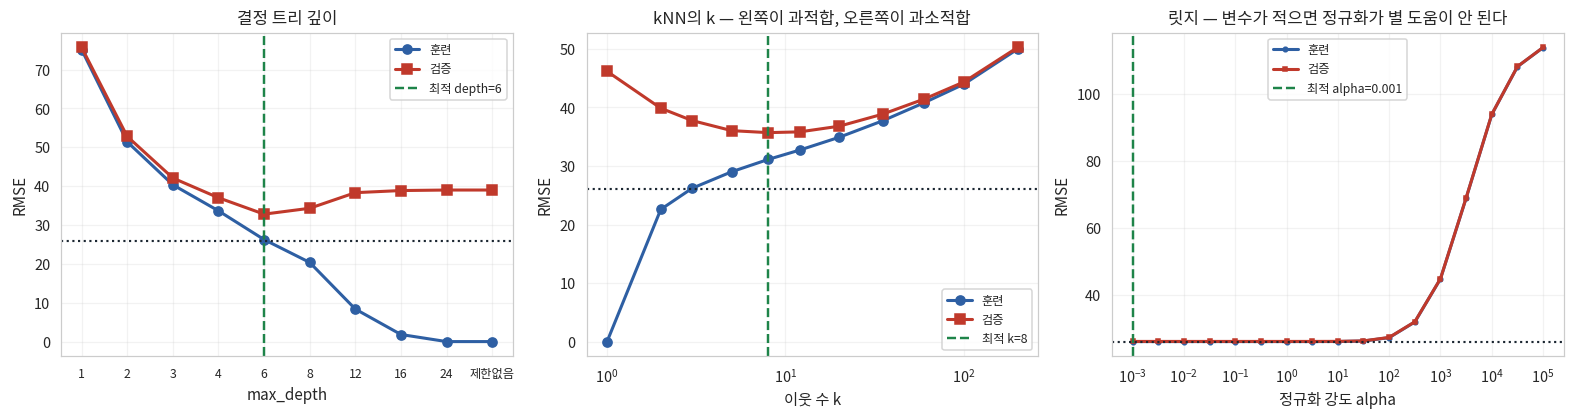

In [ ]:
# ============================================================
# 2-4. 검증곡선 — 하이퍼파라미터가 편향-분산을 어떻게 움직이는가
# ============================================================
fig, axes = panel(1, 3, w=4.8, h=3.9)

# (1) 트리 깊이
depths = [1, 2, 3, 4, 6, 8, 12, 16, 24, None]
depth_lab = [str(d) if d else "제한없음" for d in depths]
tr_s, va_s = validation_curve(DecisionTreeRegressor(random_state=0), X_all, y_all,
                              param_name="max_depth", param_range=depths,
                              cv=KFold(5, shuffle=True, random_state=0),
                              scoring="neg_root_mean_squared_error", n_jobs=-1)
xs = np.arange(len(depths))
axes[0].plot(xs, -tr_s.mean(1), "o-", color=C["blue"], lw=2, label="훈련")
axes[0].plot(xs, -va_s.mean(1), "s-", color=C["red"], lw=2, label="검증")
best = int(np.argmin(-va_s.mean(1)))
axes[0].axvline(best, color=C["green"], ls="--", lw=1.6, label=f"최적 depth={depth_lab[best]}")
axes[0].axhline(TRUE_SIGMA, color=C["dark"], ls=":", lw=1.4)
axes[0].set_xticks(xs, depth_lab, fontsize=8)
axes[0].set_xlabel("max_depth"); axes[0].set_ylabel("RMSE")
axes[0].set_title("결정 트리 깊이"); axes[0].legend(fontsize=8)

# (2) kNN의 k
ks = [1, 2, 3, 5, 8, 12, 20, 35, 60, 100, 200]
tr_s, va_s = validation_curve(Pipeline([("sc", StandardScaler()), ("m", KNeighborsRegressor())]),
                              X_all, y_all, param_name="m__n_neighbors", param_range=ks,
                              cv=KFold(5, shuffle=True, random_state=0),
                              scoring="neg_root_mean_squared_error", n_jobs=-1)
axes[1].plot(ks, -tr_s.mean(1), "o-", color=C["blue"], lw=2, label="훈련")
axes[1].plot(ks, -va_s.mean(1), "s-", color=C["red"], lw=2, label="검증")
bk = ks[int(np.argmin(-va_s.mean(1)))]
axes[1].axvline(bk, color=C["green"], ls="--", lw=1.6, label=f"최적 k={bk}")
axes[1].axhline(TRUE_SIGMA, color=C["dark"], ls=":", lw=1.4)
axes[1].set_xscale("log")
axes[1].set_xlabel("이웃 수 k"); axes[1].set_ylabel("RMSE")
axes[1].set_title("kNN의 k — 왼쪽이 과적합, 오른쪽이 과소적합")
axes[1].legend(fontsize=8)

# (3) 릿지 alpha
alphas = np.logspace(-3, 5, 17)
tr_s, va_s = validation_curve(Pipeline([("sc", StandardScaler()), ("m", Ridge())]),
                              X_all, y_all, param_name="m__alpha", param_range=alphas,
                              cv=KFold(5, shuffle=True, random_state=0),
                              scoring="neg_root_mean_squared_error", n_jobs=-1)
axes[2].plot(alphas, -tr_s.mean(1), "o-", color=C["blue"], lw=2, ms=3, label="훈련")
axes[2].plot(alphas, -va_s.mean(1), "s-", color=C["red"], lw=2, ms=3, label="검증")
ba = alphas[int(np.argmin(-va_s.mean(1)))]
axes[2].axvline(ba, color=C["green"], ls="--", lw=1.6, label=f"최적 alpha={ba:.3g}")
axes[2].axhline(TRUE_SIGMA, color=C["dark"], ls=":", lw=1.4)
axes[2].set_xscale("log")
axes[2].set_xlabel("정규화 강도 alpha"); axes[2].set_ylabel("RMSE")
axes[2].set_title("릿지 — 변수가 적으면 정규화가 별 도움이 안 된다")
axes[2].legend(fontsize=8)

fig.tight_layout(); plt.show()

### U자 곡선이 편향-분산 트레이드오프입니다

트리 깊이 그래프가 교과서 그림 그대로 나옵니다. 깊이 1에서는 훈련과 검증이 둘 다 나쁩니다. 고편향이죠. 깊이가 깊어지면 훈련 오차는 계속 내려가는데 검증 오차는 어느 지점에서 바닥을 찍고 다시 올라갑니다. 그 바닥이 최적점입니다.

kNN 쪽은 축 방향이 반대라는 점만 주의하시면 됩니다. k가 작을수록 복잡한 모델입니다. k=1이면 가장 가까운 점 하나를 그대로 베끼니 훈련 오차가 0이 되죠. k가 커지면 점점 더 넓은 범위를 평균 내니 단순해지고, 극단적으로 k가 전체 표본 수면 그냥 전체 평균, 즉 Dummy 모델이 됩니다.

릿지 그래프는 의외로 밋밋합니다. alpha를 아무리 키워도 한참 동안 성능이 안 변하다가 아주 큰 값에서 갑자기 나빠집니다. 변수가 5개뿐이고 표본이 2000개라 애초에 과적합할 여지가 없었기 때문입니다. 정규화가 필요한 상황은 변수 수가 표본 수에 비해 클 때인데 여기는 반대죠.

이 세 그림을 나란히 보면 하이퍼파라미터 튜닝이 언제 중요하고 언제 안 중요한지가 보입니다. 트리 깊이는 성능을 두 배 가까이 바꿉니다. 릿지 alpha는 거의 안 바꾸고요. 시간을 어디에 쓸지 판단하는 데 참고가 됩니다.

---

## 2-3. 모델은 무엇을 보고 있는가

성능이 비슷한 두 모델이 완전히 다른 근거로 예측할 수 있습니다. 이걸 확인하는 것이 변수 중요도입니다.

선형 모델에서는 계수를 직접 볼 수 있습니다. 다만 변수마다 단위가 다르니 표준화한 상태의 계수를 봐야 공평합니다. 트리 계열은 불순도 감소량을 합산한 내장 중요도를 제공하는데, 이 지표는 잘 알려진 편향이 있습니다. 값의 종류가 많은 연속형 변수를 과대평가하거든요. 분할 후보가 많으니 우연히 좋은 분할을 찾을 기회도 많아서입니다.

그래서 순열 중요도를 같이 봅니다. 변수 하나의 값을 무작위로 섞어서 그 변수를 망가뜨린 다음 성능이 얼마나 떨어지는지 재는 방식인데, 모델 종류와 무관하게 같은 기준으로 잴 수 있다는 장점이 있습니다. 우리는 진짜 계수를 알고 있으니 어느 쪽이 더 정확한지도 판정할 수 있고요.

선형 계열 계수 추정 (원래 스케일)
--------------------------------------------
              모델   area  rooms     age    dist  floor
           진짜 계수 4.6000 9.0000 -2.2000 -0.0280 1.1000
LinearRegression 4.5616 9.5216 -2.1235 -0.0259 1.0800
      Ridge(a=1) 4.5538 9.6698 -2.1221 -0.0259 1.0791
    Lasso(a=0.1) 4.5597 9.4442 -2.1158 -0.0257 1.0586
           Huber 4.5588 9.7805 -2.1396 -0.0252 1.1014



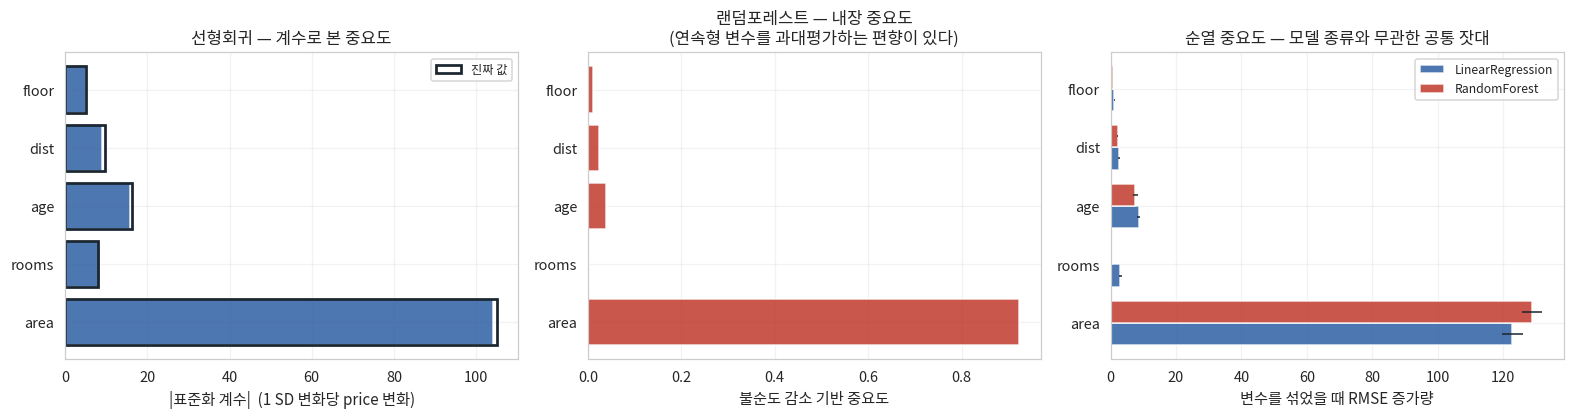

중요도 지표별 순위 비교
--------------------------------------------
   변수  진짜 기여도(|beta|×SD)  선형 표준화계수  RF 내장 중요도  RF 순열 중요도  진짜 순위  RF 내장 순위  RF 순열 순위
 area           104.9544  104.0408     0.9233   128.8253      1         1         1
rooms             8.0669    8.5314     0.0031     0.2784      4         5         5
  age            16.3680   15.7931     0.0392     7.6013      2         2         2
 dist             9.7145    8.9720     0.0239     2.1107      3         3         3
floor             5.1089    5.0141     0.0105     0.7246      5         4         4



In [ ]:
# ============================================================
# 2-5. 계수 · 내장 중요도 · 순열 중요도 비교
# ============================================================
sd_x = X_tr.std().to_numpy()

# (1) 선형 모델의 표준화 계수 -> 원래 스케일로 환산
coef_rows = [dict(zip(FEATURES, [TRUE_BETA[f] for f in FEATURES]), 모델="진짜 계수")]
for name in ["LinearRegression", "Ridge(a=1)", "Lasso(a=0.1)", "Huber"]:
    pipe = clone(MODELS[name]).fit(X_tr, y_tr)
    b = pipe.named_steps["m"].coef_ / pipe.named_steps["sc"].scale_
    coef_rows.append(dict(zip(FEATURES, b), 모델=name))
coef_df = pd.DataFrame(coef_rows)[["모델"] + FEATURES]
show_table(coef_df, "선형 계열 계수 추정 (원래 스케일)", "{:.4f}")

# (2) 중요도 세 가지를 같은 그림에
fig, axes = panel(1, 3, w=4.8, h=3.9)

# 표준화 계수의 절댓값 = 변수 1 표준편차 변화당 price 변화
lin = clone(MODELS["LinearRegression"]).fit(X_tr, y_tr)
std_coef = np.abs(lin.named_steps["m"].coef_)
axes[0].barh(FEATURES, std_coef, color=C["blue"], alpha=.85)
true_std = np.abs([TRUE_BETA[f] for f in FEATURES]) * sd_x
axes[0].barh(FEATURES, true_std, color="none", edgecolor=C["dark"], lw=1.8, label="진짜 값")
axes[0].set_xlabel("|표준화 계수|  (1 SD 변화당 price 변화)")
axes[0].set_title("선형회귀 — 계수로 본 중요도")
axes[0].legend(fontsize=8)

rf = clone(MODELS["RandomForest"]).fit(X_tr, y_tr)
axes[1].barh(FEATURES, rf.feature_importances_, color=C["red"], alpha=.85)
axes[1].set_xlabel("불순도 감소 기반 중요도")
axes[1].set_title("랜덤포레스트 — 내장 중요도\n(연속형 변수를 과대평가하는 편향이 있다)")

perm_res = {}
for name, mdl in [("LinearRegression", lin), ("RandomForest", rf)]:
    pi = permutation_importance(mdl, X_te, y_te, n_repeats=10, random_state=0,
                                scoring="neg_root_mean_squared_error", n_jobs=-1)
    perm_res[name] = pi
w = 0.38
ypos = np.arange(len(FEATURES))
axes[2].barh(ypos - w/2, perm_res["LinearRegression"].importances_mean, w,
             xerr=perm_res["LinearRegression"].importances_std,
             color=C["blue"], alpha=.85, label="LinearRegression",
             error_kw=dict(lw=1, ecolor=C["dark"]))
axes[2].barh(ypos + w/2, perm_res["RandomForest"].importances_mean, w,
             xerr=perm_res["RandomForest"].importances_std,
             color=C["red"], alpha=.85, label="RandomForest",
             error_kw=dict(lw=1, ecolor=C["dark"]))
axes[2].set_yticks(ypos, FEATURES)
axes[2].set_xlabel("변수를 섞었을 때 RMSE 증가량")
axes[2].set_title("순열 중요도 — 모델 종류와 무관한 공통 잣대")
axes[2].legend(fontsize=8)

fig.tight_layout(); plt.show()

imp_cmp = pd.DataFrame({
    "변수": FEATURES,
    "진짜 기여도(|beta|×SD)": true_std,
    "선형 표준화계수": std_coef,
    "RF 내장 중요도": rf.feature_importances_,
    "RF 순열 중요도": perm_res["RandomForest"].importances_mean,
})
imp_cmp["진짜 순위"] = imp_cmp["진짜 기여도(|beta|×SD)"].rank(ascending=False).astype(int)
imp_cmp["RF 내장 순위"] = imp_cmp["RF 내장 중요도"].rank(ascending=False).astype(int)
imp_cmp["RF 순열 순위"] = imp_cmp["RF 순열 중요도"].rank(ascending=False).astype(int)
show_table(imp_cmp, "중요도 지표별 순위 비교", "{:.4f}")

### 중요도 지표마다 순위가 다릅니다

먼저 계수 표를 보시죠. OLS와 릿지와 Huber가 진짜 계수를 거의 정확히 복원합니다. 라쏘는 조금 다른데, L1 벌점이 계수를 0 쪽으로 밀기 때문에 절댓값이 작은 `dist` 계수가 특히 영향을 받습니다. 벌점의 성격이 추정치에 그대로 드러나는 거죠.

중요도 쪽으로 가면 이야기가 복잡해집니다.

표준화 계수는 진짜 기여도와 거의 정확히 일치합니다. 데이터가 선형이고 모델이 선형이니 당연한 결과고요.

랜덤포레스트의 내장 중요도는 순위가 다르게 나옵니다. 진짜 기여도에서 하위권인 변수가 올라오거나, `rooms`처럼 값의 종류가 6개뿐인 이산 변수가 밀려납니다. 앞에서 말한 편향입니다. `area`나 `dist` 같은 연속형 변수는 분할 후보 지점이 수천 개인데 `rooms`는 다섯 개뿐이니, 불순도 감소를 누적하는 과정에서 연속형이 유리해집니다.

순열 중요도는 이 편향에서 자유롭습니다. 변수를 망가뜨렸을 때 실제 성능이 얼마나 떨어지는지를 직접 재니까요. 오차 막대도 함께 나와서 어느 변수의 중요도가 확실하고 어느 변수가 애매한지도 구분됩니다.

### 순열 중요도에도 함정이 있습니다

만능은 아닙니다. 상관이 높은 변수들이 있으면 순열 중요도가 둘 다 낮게 나옵니다. `area`를 섞어도 `rooms`가 비슷한 정보를 가지고 있어서 성능이 별로 안 떨어지고, 반대도 마찬가지거든요. 그래서 둘 다 안 중요해 보이는데, 실제로는 둘 중 하나는 꼭 필요합니다.

우리 데이터에서 `area`와 `rooms`의 상관이 높으니 이 현상이 어느 정도 나타납니다. 실무에서 순열 중요도가 예상보다 낮게 나오면 먼저 상관행렬을 확인해 보세요.

해결책으로는 상관된 변수를 묶어서 한꺼번에 섞는 방법이나, 조건부 순열 중요도, 또는 SHAP 값 같은 것들이 있습니다. 어느 것도 완벽하지 않고 각각 다른 질문에 답한다는 점을 기억해 두시면 좋겠습니다.

---

# 3부. 전처리 민감도 — 모델마다 다르다

여기가 두 노트북을 잇는 부분입니다.

앞 노트북에서 전처리 전략을 바꾸면 성능이 크게 달라진다는 것을 확인했습니다. 그런데 그 실험은 선형 모델 하나로만 했습니다. 그러니 "전처리가 중요하다"는 결론이 모든 모델에 해당하는지는 아직 모릅니다.

실무에서 이런 말을 자주 듣습니다. "부스팅 쓰면 전처리 대충 해도 돼요." 반은 맞고 반은 틀린 말인데, 어느 쪽이 맞고 어느 쪽이 틀린지를 실험으로 가려 보겠습니다.

세 가지를 재 봅니다. 스케일이 다른 변수에 대한 민감도, 결측에 대한 민감도, 그리고 이상치에 대한 민감도입니다. 각각에서 모델 그룹별로 반응이 어떻게 다른지 보고, 마지막에 하나의 히트맵으로 종합합니다.

## 3-1. 스케일링이 필요한 모델과 필요 없는 모델

먼저 가장 단순한 것부터 봅니다. 변수들의 단위가 크게 다를 때 어떤 모델이 무너지는가.

우리 데이터에서 `dist`는 수백 단위이고 `rooms`는 한 자리 수입니다. 이미 스케일 차이가 있죠. 여기에 `dist`를 미터가 아니라 밀리미터로 기록한 상황을 흉내 내어 1000배로 부풀려 보겠습니다. 실무에서 단위가 섞여 들어오는 일은 흔합니다.

거리를 쓰는 모델은 이 변화에 치명적으로 반응할 겁니다. 유클리드 거리에서 한 변수의 스케일이 1000배면 그 변수가 거리를 독점하니까요. 트리 계열은 각 변수를 독립적으로 자르고 분할 기준이 순서에만 의존하므로 영향을 안 받아야 합니다. 예측대로 되는지 봅시다.

스케일 왜곡 × 스케일링 여부 (5-fold CV RMSE)
--------------------------------------------
               모델       dist를 1000배                     원래 단위        
                  StandardScaler 적용 스케일링 없음 StandardScaler 적용 스케일링 없음
     DecisionTree             39.15   39.11             39.15   39.11
HistGradientBoost             29.67   29.67             29.68   29.67
 LinearRegression             26.21   26.21             26.21   26.21
     RandomForest             29.23   29.20             29.23   29.20
       Ridge(a=1)             26.21   26.21             26.21   26.21
         SVR(rbf)             29.73  115.54             29.73   35.10
        kNN(k=10)             35.97  107.27             35.97   46.01



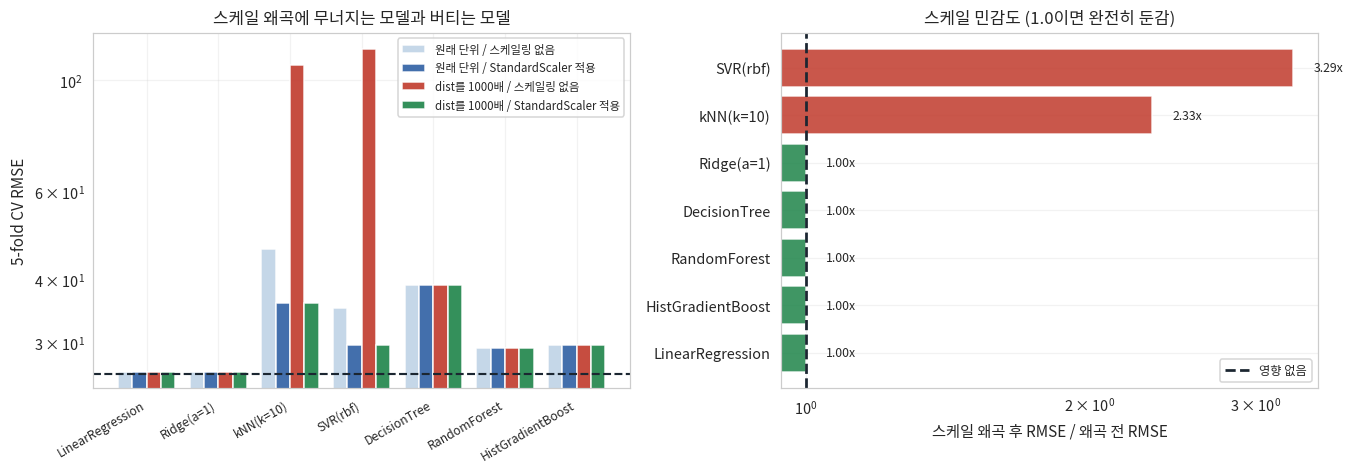

In [ ]:
# ============================================================
# 3-1. 스케일 왜곡에 대한 민감도
# ============================================================
X_scaled_bad = X_all.copy()
X_scaled_bad["dist"] = X_scaled_bad["dist"] * 1000.0    # 단위 오기록 (m -> mm)

RAW_MODELS = {   # 스케일러를 뺀 '날것' 버전
    "LinearRegression": LinearRegression(),
    "Ridge(a=1)": Ridge(alpha=1.0),
    "kNN(k=10)": KNeighborsRegressor(n_neighbors=10),
    "SVR(rbf)": SVR(C=100, gamma="scale"),
    "DecisionTree": DecisionTreeRegressor(random_state=0),
    "RandomForest": RandomForestRegressor(n_estimators=120, random_state=0, n_jobs=-1),
    "HistGradientBoost": HistGradientBoostingRegressor(random_state=0),
}

rows = []
for name, base in RAW_MODELS.items():
    for xlabel, Xd in [("원래 단위", X_all), ("dist를 1000배", X_scaled_bad)]:
        for slabel, use_scaler in [("스케일링 없음", False), ("StandardScaler 적용", True)]:
            mdl = Pipeline([("sc", StandardScaler()), ("m", clone(base))]) if use_scaler else clone(base)
            cvres = cross_validate(mdl, Xd, y_all, cv=KFold(3, shuffle=True, random_state=0),
                                   scoring="neg_root_mean_squared_error", n_jobs=-1)
            rows.append({"모델": name, "데이터": xlabel, "전처리": slabel,
                         "RMSE": float(-cvres["test_score"].mean())})
scale_df = pd.DataFrame(rows)

piv = scale_df.pivot_table(index="모델", columns=["데이터", "전처리"], values="RMSE")
show_table(piv.reset_index(), "스케일 왜곡 × 스케일링 여부 (5-fold CV RMSE)", "{:.2f}")

fig, axes = panel(1, 2, w=6.2, h=4.4)
names = list(RAW_MODELS)
w = 0.2
xs = np.arange(len(names))
combos = [("원래 단위", "스케일링 없음", C["light"]),
          ("원래 단위", "StandardScaler 적용", C["blue"]),
          ("dist를 1000배", "스케일링 없음", C["red"]),
          ("dist를 1000배", "StandardScaler 적용", C["green"])]
for i, (dl, sl, col) in enumerate(combos):
    vals = [scale_df[(scale_df["모델"] == n) & (scale_df["데이터"] == dl)
                     & (scale_df["전처리"] == sl)]["RMSE"].iloc[0] for n in names]
    axes[0].bar(xs + (i - 1.5) * w, vals, w, color=col, alpha=.9, label=f"{dl} / {sl}")
axes[0].set_xticks(xs, names, rotation=30, ha="right", fontsize=8)
axes[0].set_ylabel("5-fold CV RMSE")
axes[0].set_yscale("log")
axes[0].axhline(TRUE_SIGMA, color=C["dark"], ls="--", lw=1.4)
axes[0].set_title("스케일 왜곡에 무너지는 모델과 버티는 모델")
axes[0].legend(fontsize=7.5)

# 피해율 = (왜곡·스케일링없음) / (원래·스케일링없음)
dmg = []
for n in names:
    a = scale_df[(scale_df["모델"] == n) & (scale_df["데이터"] == "원래 단위")
                 & (scale_df["전처리"] == "스케일링 없음")]["RMSE"].iloc[0]
    b = scale_df[(scale_df["모델"] == n) & (scale_df["데이터"] == "dist를 1000배")
                 & (scale_df["전처리"] == "스케일링 없음")]["RMSE"].iloc[0]
    dmg.append(b / a)
order_i = np.argsort(dmg)
axes[1].barh([names[i] for i in order_i], [dmg[i] for i in order_i],
             color=[C["red"] if dmg[i] > 1.05 else C["green"] for i in order_i], alpha=.85)
axes[1].axvline(1.0, color=C["dark"], ls="--", lw=1.8, label="영향 없음")
axes[1].set_xscale("log")
axes[1].set_xlabel("스케일 왜곡 후 RMSE / 왜곡 전 RMSE")
axes[1].set_title("스케일 민감도 (1.0이면 완전히 둔감)")
axes[1].legend(fontsize=8)
for i, idx in enumerate(order_i):
    axes[1].text(dmg[idx] * 1.05, i, f"{dmg[idx]:.2f}x", va="center", fontsize=8)
fig.tight_layout(); plt.show()

### 예측대로, 그리고 예측과 조금 다르게

오른쪽 그래프가 요약입니다. 배율이 1.0이면 스케일 왜곡에 전혀 영향을 받지 않았다는 뜻입니다.

트리 계열은 정확히 1.00입니다. 결정 트리, 랜덤포레스트, HistGradientBoosting 모두 `dist`를 1000배로 만들어도 성능이 소수점 아래까지 동일합니다. 이유는 분명합니다. 트리의 분할 조건은 "`dist` < 임계값"인데, 모든 값에 1000을 곱하면 임계값도 1000배가 될 뿐 어떤 행이 왼쪽으로 가고 어떤 행이 오른쪽으로 가는지는 하나도 안 바뀝니다. 즉 트리는 값의 순서만 보고 크기는 안 봅니다. 단조증가 변환에 불변이라는 말이 이 뜻입니다.

kNN과 SVR은 크게 무너집니다. 두 모델 다 거리를 씁니다. `dist`가 1000배가 되면 유클리드 거리에서 `dist` 항이 제곱으로 백만 배 기여하니, 나머지 변수는 사실상 무시됩니다. kNN이 `dist` 하나만 보고 이웃을 찾게 되는 거죠.

선형회귀는 성능이 안 변합니다. 이건 약간 다른 이유입니다. 최소제곱해는 변수의 선형변환에 대해 예측값이 불변입니다. `dist`가 1000배가 되면 계수가 1000분의 1이 되어 정확히 상쇄되니까요. 다만 릿지는 이야기가 다릅니다. 벌점이 계수의 제곱합인데 계수 크기가 변하면 벌점의 효과가 변수마다 달라지거든요. 그래서 정규화가 있는 선형 모델은 반드시 스케일링이 필요합니다.

초록 막대를 보면 해결책이 확인됩니다. `StandardScaler`를 붙이면 왜곡된 데이터에서도 원래 성능이 그대로 회복됩니다. 비용이 거의 없는 안전장치죠.

### 실무 지침

트리와 앙상블은 스케일링이 불필요합니다. 붙여도 해가 되지는 않지만 파이프라인만 길어집니다. 거리나 내적을 쓰는 모델, 그러니까 kNN, SVM, PCA, 그리고 정규화가 있는 선형 모델은 스케일링이 필수입니다. 신경망도 여기 포함되고요.

다만 "스케일링이 필요 없다"와 "전처리가 필요 없다"는 다른 말입니다. 다음 두 절에서 그 차이를 보겠습니다.

---

## 3-2. 결측에 대한 민감도 — 여기서 판도가 바뀝니다

앞 노트북에서 결측 처리 전략에 따라 릿지의 성능이 크게 달라지는 것을 봤습니다. 이번에는 전략을 고정하고 모델을 바꿔 봅니다.

그리고 여기에 특별한 참가자가 하나 있습니다. `HistGradientBoostingRegressor`는 결측치를 대치 없이 그대로 받습니다. 학습할 때 각 분할마다 "결측인 행을 왼쪽으로 보낼까 오른쪽으로 보낼까"를 데이터를 보고 정하거든요. 즉 결측의 방향 자체를 학습합니다.

이게 대치보다 나을까요? 앞 노트북의 논리로 생각해 보면, 결측이 타깃과 관계있을 때 대치는 편향을 주입한다고 했습니다. 그런데 네이티브 처리는 대치를 안 하니 그 편향이 없습니다. 대신 결측 여부를 분할에 쓰므로 결측 지시변수를 쓴 것과 비슷한 효과도 납니다. 실험으로 확인해 봅시다.

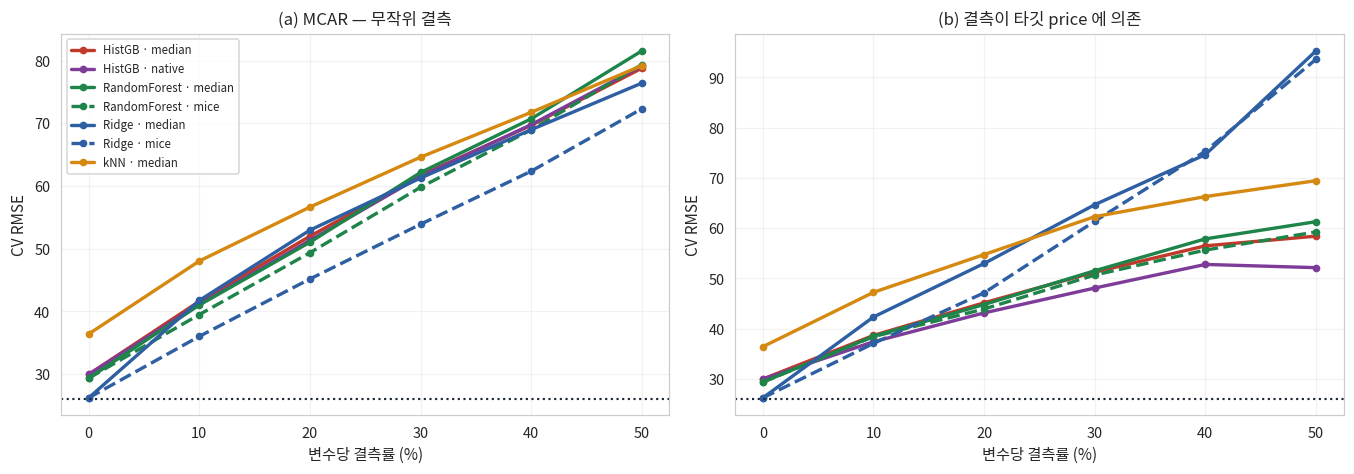

[MCAR] 평균 CV RMSE
--------------------------------------------
 결측률  HistGB · median  HistGB · native  RandomForest · median  RandomForest · mice  Ridge · median  Ridge · mice  kNN · median
0.00            29.97            29.97                  29.36                29.36           26.23         26.23         36.41
0.10            41.62            41.16                  41.03                39.51           41.76         36.03         48.05
0.20            52.00            51.34                  51.05                49.37           52.97         45.19         56.65
0.30            61.71            61.54                  62.16                59.81           61.28         53.91         64.61
0.40            69.69            69.79                  70.72                68.96           68.99         62.37         71.76
0.50            78.79            79.16                  81.56                79.38           76.41         72.32         79.21

[타깃 의존] 평균 CV RMSE
----------------------------

In [ ]:
# ============================================================
# 3-2. 결측률 × 모델 × 처리 방식
# ============================================================
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

MISS_COLS = ["area", "age", "floor", "rooms"]

def inject_missing(df, rate, driver=None, seed=0):
    r = np.random.default_rng(seed)
    d = df.copy()
    if driver is None:
        for c in MISS_COLS:
            d.loc[r.random(len(d)) < rate, c] = np.nan
    else:
        p = sigmoid(2.0 * stats.zscore(df[driver].to_numpy()))
        p = np.clip(p * (rate / p.mean()), 0, 1)
        for c in MISS_COLS:
            d.loc[r.random(len(d)) < p, c] = np.nan
    return d


def build(model_name, handling):
    # handling: "median" | "mice" | "native"
    base = {
        "Ridge": Ridge(alpha=1.0),
        "kNN": KNeighborsRegressor(n_neighbors=10),
        "RandomForest": RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1),
        "HistGB": HistGradientBoostingRegressor(random_state=0),
    }[model_name]
    needs_scale = model_name in ("Ridge", "kNN")
    steps = []
    if handling == "median":
        steps.append(("imp", SimpleImputer(strategy="median")))
    elif handling == "mice":
        steps.append(("imp", IterativeImputer(max_iter=8, random_state=0)))
    # 'native' 는 대치 단계 없음 (HistGB 전용)
    if needs_scale:
        steps.append(("sc", StandardScaler()))
    steps.append(("m", base))
    return Pipeline(steps)


rates = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50]
combos = [("Ridge", "median"), ("Ridge", "mice"),
          ("kNN", "median"), ("RandomForest", "median"),
          ("RandomForest", "mice"), ("HistGB", "median"), ("HistGB", "native")]

def run_missing_sweep(driver, label, reps=2):
    out = []
    for rate in rates:
        for rep in range(reps):
            d = inject_missing(clean, rate, driver, seed=100 + rep)
            Xd = d[FEATURES]
            for mname, h in combos:
                pipe = build(mname, h)
                cvres = cross_validate(pipe, Xd, y_all,
                                       cv=KFold(3, shuffle=True, random_state=rep),
                                       scoring="neg_root_mean_squared_error", n_jobs=-1)
                out.append({"결측률": rate, "모델": mname, "처리": h,
                            "이름": f"{mname} · {h}",
                            "RMSE": float(-cvres["test_score"].mean()), "조건": label})
    return pd.DataFrame(out)


ms_mcar = run_missing_sweep(None, "MCAR")
ms_tgt = run_missing_sweep("price", "타깃 의존")

style = {
    "Ridge · median": (C["blue"], "-"), "Ridge · mice": (C["blue"], "--"),
    "kNN · median": (C["amber"], "-"),
    "RandomForest · median": (C["green"], "-"), "RandomForest · mice": (C["green"], "--"),
    "HistGB · median": (C["red"], "-"), "HistGB · native": (C["purple"], "-"),
}

fig, axes = panel(1, 2, w=6.2, h=4.4)
for ax, (df_, ttl) in zip(axes, [(ms_mcar, "(a) MCAR — 무작위 결측"),
                                 (ms_tgt, "(b) 결측이 타깃 price 에 의존")]):
    pv = df_.groupby(["결측률", "이름"])["RMSE"].mean().unstack()
    for col in pv.columns:
        c_, ls_ = style[col]
        ax.plot(pv.index * 100, pv[col], ls_, color=c_, lw=2.2, marker="o", ms=4, label=col)
    ax.axhline(TRUE_SIGMA, color=C["dark"], ls=":", lw=1.4)
    ax.set_xlabel("변수당 결측률 (%)"); ax.set_ylabel("CV RMSE")
    ax.set_title(ttl)
axes[0].legend(fontsize=7.5)
fig.tight_layout(); plt.show()

for df_, lab in [(ms_mcar, "MCAR"), (ms_tgt, "타깃 의존")]:
    show_table(df_.groupby(["결측률", "이름"])["RMSE"].mean().unstack().reset_index(),
               f"[{lab}] 평균 CV RMSE", "{:.2f}")

### 결측에는 모든 모델이 약합니다. 정도만 다릅니다

먼저 오해를 하나 풀고 가겠습니다. "트리 계열은 결측에 강하다"는 말이 종종 돌아다니는데, 두 패널 모두에서 랜덤포레스트도 결측률이 올라가면 성능이 확실히 떨어집니다. 당연한 일입니다. 정보가 사라졌으니까요. 트리가 강한 것은 스케일과 지렛대점에 대해서이지 결측에 대해서가 아닙니다. sklearn의 `RandomForestRegressor`는 애초에 NaN을 받지도 못해서 반드시 대치가 필요합니다.

(a) MCAR에서는 대치 방법이 모델 선택보다 더 크게 작용합니다. 결측률 50% 지점을 보시면 같은 릿지인데 median 대치가 79, MICE 대치가 72입니다. 7 정도 차이죠. 반면 같은 median 대치를 쓴 모델끼리는 79에서 82 사이에 몰려 있어서 3 정도밖에 안 벌어집니다.

모델 선택에 시간을 쏟기 전에 대치 전략을 점검하는 편이 낫다는 뜻입니다. 앞 노트북에서 MCAR일 때 MICE가 강했던 것과도 일관됩니다.

(a)에서 HistGB의 네이티브 처리와 median 대치는 거의 같습니다. 보라색과 빨간색이 붙어 있죠. 결측이 무작위면 중앙값으로 채워도 편향이 생기지 않으니, 네이티브 처리가 특별히 유리할 이유가 없습니다.

(b)에서 그림이 달라집니다. 결측이 타깃에 의존하는 조건에서는 모든 곡선이 위로 치솟는데, 유독 보라색 선만 완만합니다. 결측률 50%에서 네이티브가 52 근처인데 median 대치는 58, MICE도 비슷하고, 릿지는 95까지 갑니다.

앞 노트북에서 설명한 구조가 그대로 작동한 겁니다. 대치기는 타깃을 볼 수 없으니 결측의 원인을 모르는 채로 관측된 행만 보고 학습합니다. 그 행들이 저가 쪽으로 치우쳐 있으니 결측 행의 면적을 체계적으로 작게 채우고, 그 가짜 패턴이 모델을 비틉니다. 네이티브 처리는 애초에 값을 만들어 넣지 않으니 이 함정을 피해 가고, 게다가 결측 여부 자체를 분할 기준으로 쓸 수 있어서 결측 지시변수의 효과까지 덤으로 얻습니다.

릿지가 (b)에서 가장 심하게 무너지는 것도 짚어 둘 만합니다. 선형 모델은 모든 행이 하나의 계수 집합을 공유하니, 대치가 주입한 편향이 계수를 통째로 끌고 갑니다. 트리 계열은 편향이 특정 분기 아래에만 갇히고요.

### 정리하면

결측이 많고 메커니즘이 의심스러운 데이터라면 `HistGradientBoosting`의 네이티브 처리가 실용적인 선택입니다. 반대로 MCAR이라고 믿을 근거가 있다면 굳이 이 모델을 고를 이유가 없고, 좋은 대치기를 쓰는 편이 낫습니다.

어느 쪽이든 만능은 아닙니다. 계수를 해석해야 한다면 이 모델은 쓸 수 없고, 결측률이 아주 높으면 이 모델도 결국 무너집니다. 정보가 없으면 아무도 못 맞힙니다.

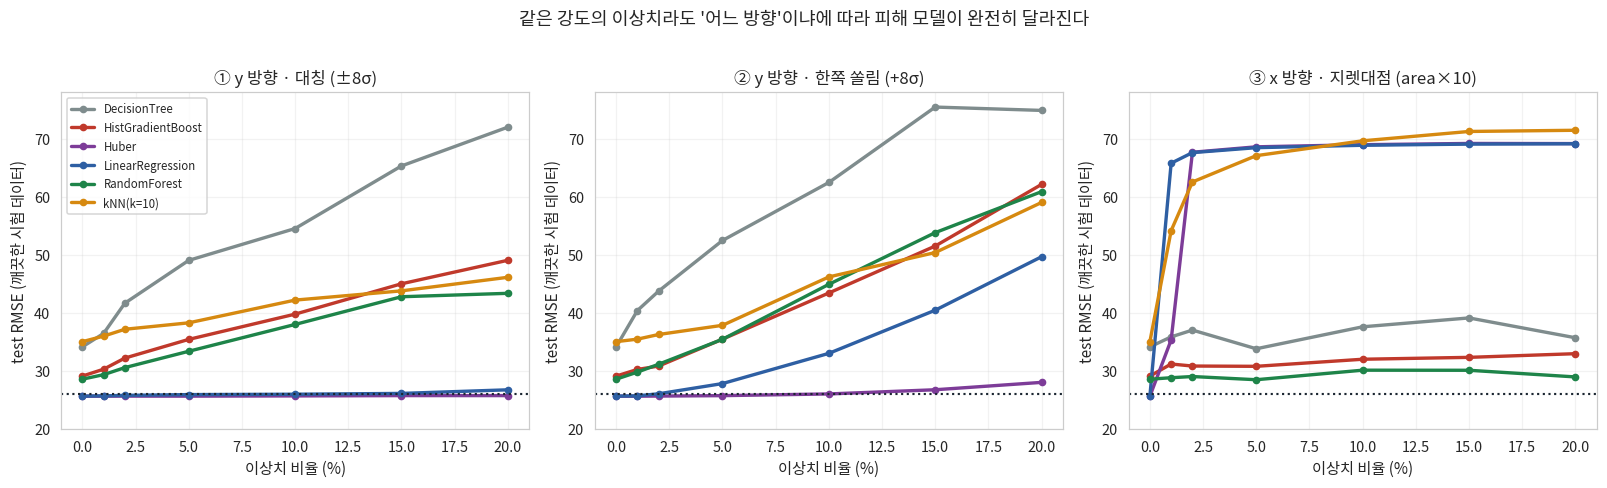

[① y 방향 · 대칭 (±8σ)] 평균 test RMSE
--------------------------------------------
 이상치 비율  DecisionTree  HistGradientBoost  Huber  LinearRegression  RandomForest  kNN(k=10)
   0.00         34.17              29.15  25.68             25.70         28.61      35.07
   0.01         36.48              30.33  25.68             25.74         29.39      36.02
   0.02         41.70              32.24  25.69             25.82         30.60      37.20
   0.05         49.06              35.46  25.69             25.96         33.41      38.31
   0.10         54.55              39.81  25.73             26.02         38.03      42.22
   0.15         65.32              45.03  25.78             26.16         42.80      43.82
   0.20         72.00              49.08  25.78             26.78         43.39      46.15

[② y 방향 · 한쪽 쏠림 (+8σ)] 평균 test RMSE
--------------------------------------------
 이상치 비율  DecisionTree  HistGradientBoost  Huber  LinearRegression  RandomForest  kNN(k=10)
   0.00         34.17

In [ ]:
# ============================================================
# 3-3. 이상치 유형 × 비율 × 모델
# ============================================================
def inject_outliers(df, rate, kind, seed=0, strength=8.0):
    # kind = "y_sym"  : 타깃에 +-8sigma 를 무작위 부호로 더한다 (대칭 오염)
    #        "y_asym" : 타깃에 +8sigma 만 더한다 (한쪽으로 쏠린 오염)
    #        "x"      : area 를 10배로 만든다 (지렛대점)
    r = np.random.default_rng(seed)
    d = df.copy()
    k = int(len(d) * rate)
    if k == 0:
        return d
    idx = r.choice(len(d), k, replace=False)
    if kind == "y_sym":
        d.loc[d.index[idx], "price"] += r.choice([-1, 1], k) * strength * TRUE_SIGMA
    elif kind == "y_asym":
        d.loc[d.index[idx], "price"] += strength * TRUE_SIGMA
    else:
        d.loc[d.index[idx], "area"] *= 10
    return d


OUT_MODELS = {
    "LinearRegression": Pipeline([("sc", StandardScaler()), ("m", LinearRegression())]),
    "Huber": Pipeline([("sc", StandardScaler()),
                       ("m", HuberRegressor(epsilon=1.35, alpha=1e-4, max_iter=800))]),
    "kNN(k=10)": Pipeline([("sc", StandardScaler()), ("m", KNeighborsRegressor(n_neighbors=10))]),
    "DecisionTree": DecisionTreeRegressor(random_state=0, max_depth=8),
    "RandomForest": RandomForestRegressor(n_estimators=150, random_state=0, n_jobs=-1),
    "HistGradientBoost": HistGradientBoostingRegressor(random_state=0),
}

orates = [0.0, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20]
KINDS = [("y_sym", "① y 방향 · 대칭 (±8σ)"),
         ("y_asym", "② y 방향 · 한쪽 쏠림 (+8σ)"),
         ("x", "③ x 방향 · 지렛대점 (area×10)")]
rows = []
for kind, klabel in KINDS:
    for rate in orates:
        for rep in range(2):
            d = inject_outliers(clean, rate, kind, seed=200 + rep)
            Xd, yd = d[FEATURES], d[TARGET]
            for name, mdl in OUT_MODELS.items():
                m = clone(mdl).fit(Xd.iloc[:1400], yd.iloc[:1400])
                # 평가는 언제나 깨끗한 원본으로
                pred = m.predict(clean[FEATURES].iloc[1400:])
                rmse = float(np.sqrt(mean_squared_error(clean[TARGET].iloc[1400:], pred)))
                rows.append({"유형": klabel, "이상치 비율": rate, "모델": name, "RMSE": rmse})
out_df = pd.DataFrame(rows)

MCOL = {"LinearRegression": C["blue"], "Huber": C["purple"], "kNN(k=10)": C["amber"],
        "DecisionTree": C["gray"], "RandomForest": C["green"], "HistGradientBoost": C["red"]}

fig, axes = panel(1, 3, w=4.9, h=4.3)
for ax, (_, klabel) in zip(axes, KINDS):
    pv = out_df[out_df["유형"] == klabel].groupby(["이상치 비율", "모델"])["RMSE"].mean().unstack()
    for col in pv.columns:
        ax.plot(pv.index * 100, pv[col], "o-", lw=2.2, ms=4, color=MCOL[col], label=col)
    ax.axhline(TRUE_SIGMA, color=C["dark"], ls=":", lw=1.4)
    ax.set_xlabel("이상치 비율 (%)"); ax.set_ylabel("test RMSE (깨끗한 시험 데이터)")
    ax.set_ylim(20, 78)
    ax.set_title(klabel)
axes[0].legend(fontsize=7.5)
fig.suptitle("같은 강도의 이상치라도 '어느 방향'이냐에 따라 피해 모델이 완전히 달라진다",
             y=1.02, fontsize=12)
fig.tight_layout(); plt.show()

for _, klabel in KINDS:
    show_table(out_df[out_df["유형"] == klabel]
               .groupby(["이상치 비율", "모델"])["RMSE"].mean().unstack().reset_index(),
               f"[{klabel}] 평균 test RMSE", "{:.2f}")

### 예상과 다른 결과가 나왔습니다

세 패널의 순위가 전부 다릅니다. 하나씩 보겠습니다.

① y 방향 대칭 오염. 선형 모델이 거의 꿈쩍도 안 합니다. 파란 선과 보라 선이 이상치 20%까지도 26 근처에 붙어 있죠. 반대로 단독 트리가 72까지 치솟고, kNN과 부스팅과 랜덤포레스트도 확연히 올라갑니다.

직관과 반대죠. 이상치에 약한 것이 선형 모델이라고 배웠는데요. 그런데 수식을 보면 설명이 됩니다.

우리가 넣은 오염은 $\pm 8\sigma$ 를 무작위 부호로 더한 것이라 기댓값이 0입니다. 그러면 오차항의 평균이 여전히 0이므로 최소제곱 추정량은 **불편**입니다. 계수가 편향되지 않고 분산만 커집니다. 그런데 표본이 1400개나 되니 그 분산 증가가 계수 추정에 거의 영향을 못 줍니다. 위로 튄 점과 아래로 튄 점이 서로 상쇄되는 거죠.

트리와 kNN은 사정이 다릅니다. 이들은 **국소적으로** 평균을 냅니다. 잎 하나에 데이터가 스무 개쯤 들어 있는데 그중 하나가 $8\sigma$ 짜리면 그 잎의 예측값이 통째로 밀립니다. 상쇄시킬 상대가 같은 잎 안에 없으니까요. 전역 평균화의 힘이 여기서 드러납니다.

② y 방향 한쪽 쏠림. 부호를 $+8\sigma$ 로 고정하기만 했는데 그림이 뒤집힙니다. OLS가 올라가기 시작하고, Huber는 여전히 낮게 유지됩니다.

이제 오차의 평균이 0이 아니니 OLS가 편향됩니다. 주로 절편이 밀리고 이상치가 특정 구간에 몰리면 기울기도 움직입니다. Huber는 큰 잔차의 기여를 상수로 묶어서 이 편향을 막아 내고요. 로버스트 손실이 필요한 상황은 정확히 여기입니다.

③ x 방향 지렛대점. 세 번째 패널이 가장 극적입니다. 이상치 비율이 1~2%만 되어도 OLS와 Huber와 kNN이 26에서 68로 수직 상승합니다. 반면 트리 계열은 28에서 33 사이를 유지합니다.

Huber가 OLS와 똑같이 무너진다는 점이 핵심입니다. 앞 노트북에서 설명했듯이, `area`를 10배로 만들면 회귀선이 그 점으로 끌려가고 끌려간 뒤에는 잔차가 작아집니다. 작은 잔차는 Huber의 제곱 구간 안에 있으니 Huber 입장에서는 정상적인 점으로 보이죠. 손실 함수는 잔차만 보지 입력값이 얼마나 극단적인지는 보지 않습니다.

트리가 버티는 이유는 3-1절에서 본 성질 덕입니다. `area`가 600이든 60이든 트리에게는 그냥 "임계값보다 큰 쪽"일 뿐입니다. 스케일 불변성이 지렛대점 내성으로 이어진 겁니다.

### 앞 노트북과 이어서 읽기

앞 노트북 3-3절에서 Huber가 제거 전략에 크게 밀렸던 것이 이제 완전히 설명됩니다. 그 실험에서 주입한 이상치는 대칭 y 오염과 x 지렛대점의 혼합이었습니다. 대칭 y 오염은 애초에 OLS에 별 피해를 못 주고, 지렛대점은 Huber가 못 막습니다. 그러니 Huber가 얻을 것이 거의 없었던 거죠. 성능을 끌어올린 것은 IQR이나 Isolation Forest로 지렛대점을 **탐지해서 제거**한 쪽이었습니다.

### 실무에서 쓸 판단 규칙

이상치를 발견하면 세 가지를 순서대로 확인하세요.

첫째, 타깃 쪽인가 입력 쪽인가. 입력 쪽이면 손실 함수로는 해결이 안 됩니다. 탐지해서 제거하거나 값을 자르거나 트리 계열로 가야 합니다.

둘째, 타깃 쪽이라면 한쪽으로 쏠려 있는가. 대칭이면 선형 모델은 표본이 충분할 때 알아서 견딥니다. 쏠려 있으면 로버스트 손실이 필요하고요.

셋째, 국소적인 모델을 쓰고 있는가. 트리와 kNN은 y 방향 이상치에 오히려 더 취약합니다. 이들을 쓴다면 y 이상치를 반드시 처리해야 합니다.

세 번째가 특히 자주 간과됩니다. "부스팅은 이상치에 강하다"는 말이 돌아다니는데, ① 패널을 보면 y 방향 이상치에서 부스팅이 선형 모델보다 훨씬 나쁩니다. 강한 것은 x 방향에 대해서지 y 방향에 대해서가 아닙니다.

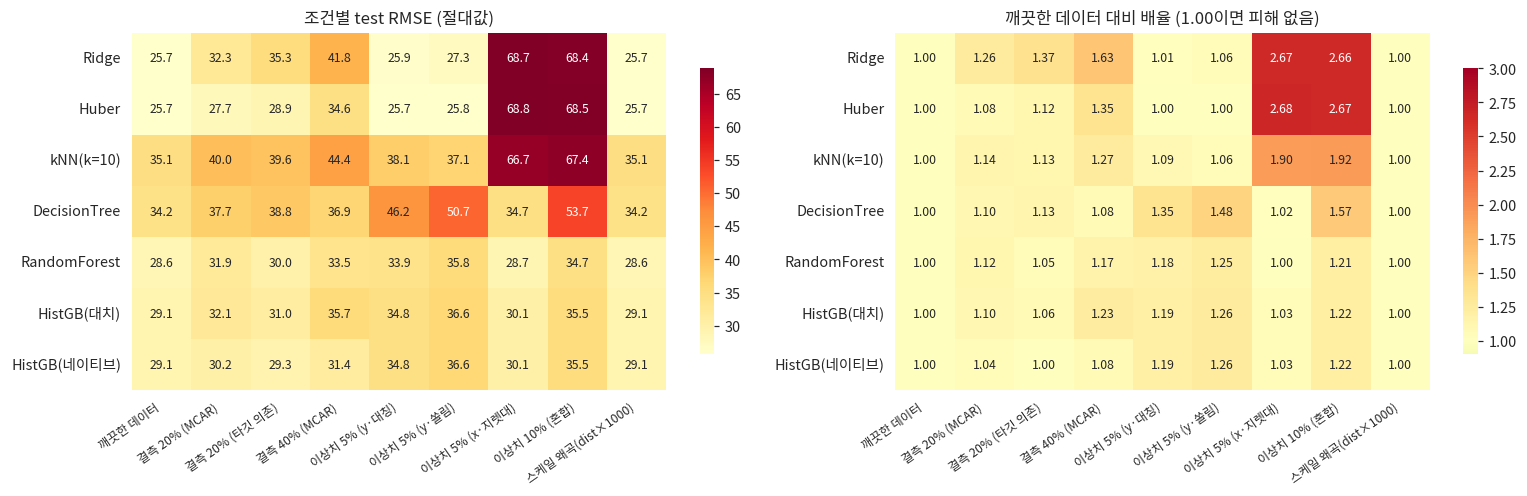

조건 × 모델 test RMSE
--------------------------------------------
          모델  깨끗한 데이터  결측 20% (MCAR)  결측 20% (타깃 의존)  결측 40% (MCAR)  이상치 5% (y·대칭)  이상치 5% (y·쏠림)  이상치 5% (x·지렛대)  이상치 10% (혼합)  스케일 왜곡(dist×1000)
       Ridge    25.70          32.33           35.29          41.80          25.87          27.34           68.66         68.38              25.70
       Huber    25.68          27.71           28.85          34.64          25.71          25.76           68.82         68.49              25.68
   kNN(k=10)    35.07          40.03           39.59          44.38          38.14          37.12           66.73         67.40              35.07
DecisionTree    34.17          37.69           38.77          36.91          46.17          50.71           34.74         53.74              34.17
RandomForest    28.61          31.93           30.02          33.52          33.89          35.77           28.74         34.74              28.61
  HistGB(대치)    29.15          32.08           31.03   

In [ ]:
# ============================================================
# 3-4. 종합 — 오염 조건별 성능 저하율 히트맵
# ============================================================
# 각 조건은 (훈련용 데이터, 시험용 특징행렬)을 돌려준다.
# 결측·이상치는 '수집 사고'이므로 훈련 데이터에만 넣고 시험은 깨끗한 원본으로 평가한다.
# 반면 스케일 왜곡은 '단위 규약'이라 훈련과 시험에 똑같이 적용해야 공정한 비교가 된다.
X_clean_te = clean[FEATURES].iloc[1400:]
y_clean_te = clean[TARGET].iloc[1400:]

conditions = {
    "깨끗한 데이터":
        lambda: (clean.copy(), X_clean_te),
    "결측 20% (MCAR)":
        lambda: (inject_missing(clean, 0.20, None, seed=1), X_clean_te),
    "결측 20% (타깃 의존)":
        lambda: (inject_missing(clean, 0.20, "price", seed=1), X_clean_te),
    "결측 40% (MCAR)":
        lambda: (inject_missing(clean, 0.40, None, seed=1), X_clean_te),
    "이상치 5% (y·대칭)":
        lambda: (inject_outliers(clean, 0.05, "y_sym", seed=1), X_clean_te),
    "이상치 5% (y·쏠림)":
        lambda: (inject_outliers(clean, 0.05, "y_asym", seed=1), X_clean_te),
    "이상치 5% (x·지렛대)":
        lambda: (inject_outliers(clean, 0.05, "x", seed=1), X_clean_te),
    "이상치 10% (혼합)":
        lambda: (inject_outliers(inject_outliers(clean, 0.05, "y_asym", seed=2), 0.05, "x", seed=3),
                 X_clean_te),
    "스케일 왜곡(dist×1000)":
        lambda: (clean.assign(dist=clean["dist"] * 1000),
                 clean[FEATURES].iloc[1400:].assign(dist=clean["dist"].iloc[1400:] * 1000)),
}

HEAT_MODELS = {
    "Ridge": Pipeline([("imp", SimpleImputer(strategy="median")),
                       ("sc", StandardScaler()), ("m", Ridge(alpha=1.0))]),
    "Huber": Pipeline([("imp", SimpleImputer(strategy="median")),
                       ("sc", StandardScaler()),
                       ("m", HuberRegressor(epsilon=1.35, alpha=1e-4, max_iter=800))]),
    "kNN(k=10)": Pipeline([("imp", SimpleImputer(strategy="median")),
                           ("sc", StandardScaler()), ("m", KNeighborsRegressor(n_neighbors=10))]),
    "DecisionTree": Pipeline([("imp", SimpleImputer(strategy="median")),
                              ("m", DecisionTreeRegressor(random_state=0, max_depth=8))]),
    "RandomForest": Pipeline([("imp", SimpleImputer(strategy="median")),
                              ("m", RandomForestRegressor(n_estimators=150, random_state=0,
                                                          n_jobs=-1))]),
    "HistGB(대치)": Pipeline([("imp", SimpleImputer(strategy="median")),
                              ("m", HistGradientBoostingRegressor(random_state=0))]),
    "HistGB(네이티브)": Pipeline([("m", HistGradientBoostingRegressor(random_state=0))]),
}

heat = pd.DataFrame(index=list(HEAT_MODELS), columns=list(conditions), dtype=float)
for cname, fn in conditions.items():
    d, X_eval = fn()
    Xd, yd = d[FEATURES], d[TARGET]
    for mname, mdl in HEAT_MODELS.items():
        m = clone(mdl).fit(Xd.iloc[:1400], yd.iloc[:1400])
        pred = m.predict(X_eval)
        heat.loc[mname, cname] = float(np.sqrt(mean_squared_error(y_clean_te, pred)))

ratio = heat.div(heat["깨끗한 데이터"], axis=0)

fig, axes = panel(1, 2, w=7.2, h=4.6)
sns.heatmap(heat.astype(float), annot=True, fmt=".1f", cmap="YlOrRd",
            ax=axes[0], cbar_kws={"shrink": .8}, annot_kws={"size": 8})
axes[0].set_title("조건별 test RMSE (절대값)")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha="right", fontsize=8)

sns.heatmap(ratio.astype(float), annot=True, fmt=".2f", cmap="RdYlGn_r", center=1.0,
            vmin=0.9, vmax=3.0, ax=axes[1], cbar_kws={"shrink": .8}, annot_kws={"size": 8})
axes[1].set_title("깨끗한 데이터 대비 배율 (1.00이면 피해 없음)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha="right", fontsize=8)
fig.tight_layout(); plt.show()

show_table(heat.reset_index().rename(columns={"index": "모델"}),
           "조건 × 모델 test RMSE", "{:.2f}")

summary = pd.DataFrame({
    "모델": ratio.index,
    "평균 피해 배율": ratio.drop(columns=["깨끗한 데이터"]).mean(axis=1).to_numpy(),
    "최악 조건": ratio.drop(columns=["깨끗한 데이터"]).idxmax(axis=1).to_numpy(),
    "최악 배율": ratio.drop(columns=["깨끗한 데이터"]).max(axis=1).to_numpy(),
    "깨끗할 때 RMSE": heat["깨끗한 데이터"].to_numpy(),
}).sort_values("평균 피해 배율")
show_table(summary, "모델별 오염 내성 종합", "{:.3f}")

### 히트맵 한 장이 3부의 결론입니다

왼쪽은 절대 성능이고 오른쪽은 깨끗한 데이터 대비 배율입니다. 두 장을 같이 봐야 합니다. 절대 성능이 좋아도 오염에 약하면 운영에서 위험하고, 오염에 강해도 절대 성능이 나쁘면 쓸 이유가 없으니까요.

릿지는 깨끗할 때 가장 좋지만 특정 오염에 치명적으로 약합니다. 첫 번째 열에서 26 근처로 최고 성적을 내는데, x 지렛대점 열에서 2.67배로 뜁니다. 반면 y 대칭 오염 열에서는 1.01로 멀쩡하죠. 3-3절에서 본 대로 오염의 종류를 구분해서 봐야 합니다.

트리 계열은 그 반대 패턴입니다. x 지렛대점 열에서 1.00에서 1.03으로 거의 피해가 없는데, y 대칭 오염 열에서는 오히려 릿지보다 나쁩니다. 단독 트리가 1.35, 랜덤포레스트가 1.18입니다. 강점과 약점이 선형 모델과 정확히 맞바뀌어 있습니다.

그래서 혼합 열이 의미가 있습니다. 실제 데이터에는 두 유형이 섞여 있고, 그 조건에서는 모든 모델이 피해를 봅니다. 배율이 가장 낮은 랜덤포레스트도 1.21이고요. 어떤 모델도 이상치 처리를 대신해 주지 못한다는 뜻입니다.

HistGB 네이티브가 타깃 의존 결측 열에서 1.00입니다. 같은 모델을 중앙값 대치와 함께 쓰면 1.06인데, 대치를 빼니 피해가 사라졌습니다. 대치가 피해의 원인이었다는 뜻이죠. 3-2절의 결론이 히트맵에서도 확인됩니다.

스케일 왜곡 열은 전부 1.00입니다. 트리 계열은 3-1절에서 본 대로 단조변환에 불변이고, 나머지 모델은 파이프라인에 `StandardScaler`가 들어 있어서 보호를 받습니다. 스케일 문제는 이렇게 파이프라인 한 줄로 완전히 해결되는 유일한 항목입니다. 결측이나 이상치와 달리 정보 손실이 없는 문제라서 그렇습니다.

참고로 이 열을 계산할 때는 시험 데이터에도 같은 변환을 적용했습니다. 스케일 왜곡은 결측이나 이상치와 성격이 다르기 때문입니다. 결측과 이상치는 수집 사고라서 훈련 데이터에만 생기고 시험은 깨끗한 기준으로 평가하는 것이 맞지만, 단위 규약이 바뀐 것은 데이터 전체에 적용되는 이야기니까요. 훈련만 밀리미터로 바꾸고 시험은 미터로 두면 스케일 민감도가 아니라 훈련-시험 불일치를 재게 됩니다.

### 종합표를 읽는 법

마지막 표에 모델별 평균 피해 배율과 최악 조건이 정리되어 있습니다. 실무에서 모델을 고를 때 이 두 축을 같이 봐야 합니다.

데이터 품질이 보장되고 파이프라인이 안정적이라면 깨끗할 때 성능이 좋은 모델을 고르면 됩니다. 반면 데이터가 외부에서 들어오고 품질이 들쭉날쭉하다면, 평균 피해 배율이 낮은 모델이 운영 리스크를 줄여 줍니다.

그리고 어느 경우든, 전처리를 제대로 하면 두 축 모두에서 이득을 봅니다. "부스팅 쓰면 전처리 대충 해도 된다"는 말은 스케일링에 한해서는 맞고, 결측과 이상치에 대해서는 절반만 맞습니다. 히트맵의 어느 칸도 1.00이 아니라는 사실이 그 증거입니다.

---

## 3-5. 진짜 함수가 비선형이면 순위가 뒤집힙니다

지금까지의 결과에는 큰 전제가 하나 깔려 있었습니다. 데이터를 선형으로 만들었다는 것이죠. 그러니 선형 모델이 이긴 것은 당연했고, 이 결과만 보고 "선형회귀가 랜덤포레스트보다 낫다"고 말하면 틀립니다.

전제를 바꿔 보겠습니다. 같은 변수들을 쓰되 타깃을 비선형으로 만듭니다. 면적의 효과가 체감하고, 역까지의 거리가 어느 지점부터 급격히 영향을 주고, 면적과 연식 사이에 상호작용이 있는 구조입니다. 실제 부동산 가격이 이런 성격을 가진다는 건 상식적으로도 납득이 가죠.

모델은 하나도 안 바꾸고 데이터만 바꿔서 같은 교차검증을 돌립니다.

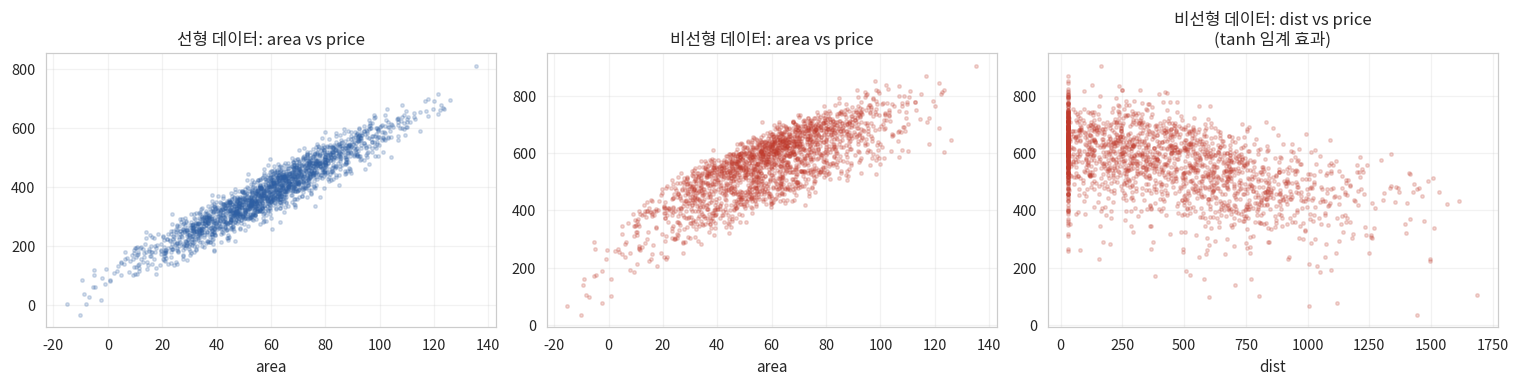

같은 모델, 다른 진짜 함수
--------------------------------------------
               모델  비선형 데이터  선형 데이터  순위(선형)  순위(비선형)  순위 변화
     DecisionTree    40.15   39.00       8        8      0
        Dummy(평균)   118.75  116.84       9        9      0
HistGradientBoost    29.91   29.77       6        2      4
            Huber    32.97   26.19       4        6     -2
     Lasso(a=0.1)    32.85   26.18       3        3      0
 LinearRegression    32.86   26.18       1        5     -4
     RandomForest    29.07   28.81       5        1      4
       Ridge(a=1)    32.86   26.18       2        4     -2
        kNN(k=10)    35.10   35.60       7        7      0



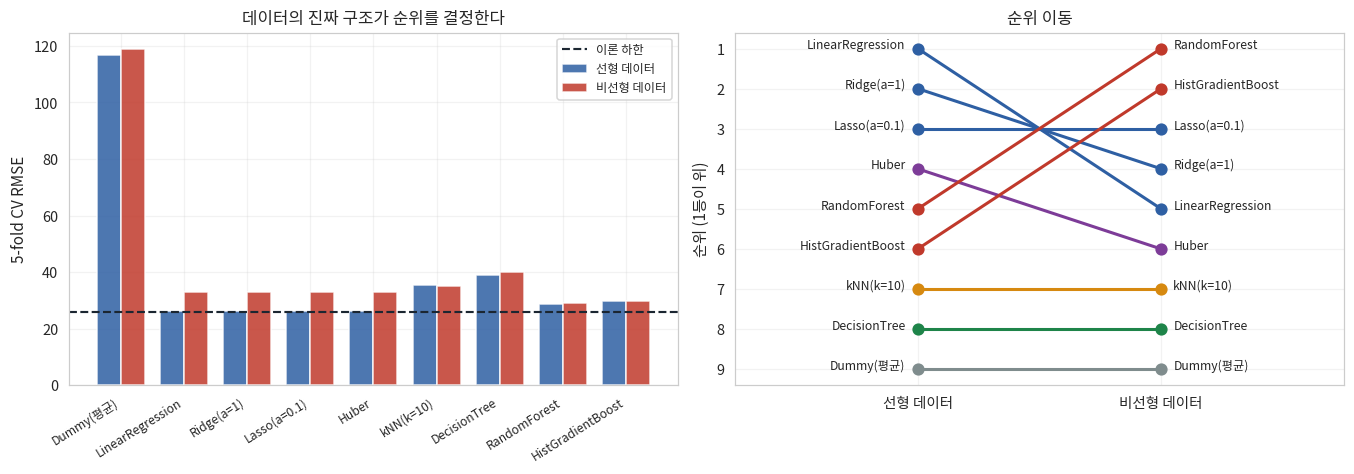

In [ ]:
# ============================================================
# 3-5. 비선형 데이터에서 다시 비교
# ============================================================
def make_nonlinear(df, seed=7, sigma=26.0):
    r = np.random.default_rng(seed)
    a, rm, ag, ds, fl = (df["area"].to_numpy(), df["rooms"].to_numpy(),
                         df["age"].to_numpy(), df["dist"].to_numpy(), df["floor"].to_numpy())
    price = (120
             + 55 * np.sqrt(np.clip(a, 1, None))          # 면적 효과 체감
             + 9 * rm
             - 2.2 * ag
             - 70 * np.tanh((ds - 600) / 250)             # 역세권 임계 효과
             + 0.0035 * a * (20 - ag)                     # 면적 × 연식 상호작용
             + 1.1 * fl
             + r.normal(0, sigma, len(df)))
    return price


y_nl = pd.Series(make_nonlinear(clean), name="price_nl")

fig, axes = panel(1, 3, w=4.6, h=3.6)
axes[0].scatter(clean["area"], y_all, s=5, alpha=.2, color=C["blue"])
axes[0].set_title("선형 데이터: area vs price"); axes[0].set_xlabel("area")
axes[1].scatter(clean["area"], y_nl, s=5, alpha=.2, color=C["red"])
axes[1].set_title("비선형 데이터: area vs price"); axes[1].set_xlabel("area")
axes[2].scatter(clean["dist"], y_nl, s=5, alpha=.2, color=C["red"])
axes[2].set_title("비선형 데이터: dist vs price\n(tanh 임계 효과)"); axes[2].set_xlabel("dist")
fig.tight_layout(); plt.show()

rows = []
for name, model in MODELS.items():
    for ylab, yv in [("선형 데이터", y_all), ("비선형 데이터", y_nl)]:
        cvres = cross_validate(clone(model), X_all, yv, cv=CV,
                               scoring="neg_root_mean_squared_error", n_jobs=-1)
        rows.append({"모델": name, "데이터": ylab, "CV RMSE": float(-cvres["test_score"].mean())})
nl_df = pd.DataFrame(rows)
nl_piv = nl_df.pivot(index="모델", columns="데이터", values="CV RMSE")
nl_piv["순위(선형)"] = nl_piv["선형 데이터"].rank().astype(int)
nl_piv["순위(비선형)"] = nl_piv["비선형 데이터"].rank().astype(int)
nl_piv["순위 변화"] = nl_piv["순위(선형)"] - nl_piv["순위(비선형)"]
show_table(nl_piv.reset_index(), "같은 모델, 다른 진짜 함수", "{:.2f}")

fig, axes = panel(1, 2, w=6.2, h=4.4)
names = list(MODELS)
xs = np.arange(len(names))
w = 0.38
axes[0].bar(xs - w/2, [nl_piv.loc[n, "선형 데이터"] for n in names], w,
            color=C["blue"], alpha=.85, label="선형 데이터")
axes[0].bar(xs + w/2, [nl_piv.loc[n, "비선형 데이터"] for n in names], w,
            color=C["red"], alpha=.85, label="비선형 데이터")
axes[0].axhline(TRUE_SIGMA, color=C["dark"], ls="--", lw=1.4, label="이론 하한")
axes[0].set_xticks(xs, names, rotation=32, ha="right", fontsize=8)
axes[0].set_ylabel("5-fold CV RMSE")
axes[0].set_title("데이터의 진짜 구조가 순위를 결정한다")
axes[0].legend(fontsize=8)

for n in names:
    axes[1].plot([0, 1], [nl_piv.loc[n, "순위(선형)"], nl_piv.loc[n, "순위(비선형)"]],
                 "o-", lw=2, ms=7, color=GROUP_COLOR[MODEL_GROUP[n]])
    axes[1].annotate(n, (0, nl_piv.loc[n, "순위(선형)"]), textcoords="offset points",
                     xytext=(-8, 0), ha="right", fontsize=8)
    axes[1].annotate(n, (1, nl_piv.loc[n, "순위(비선형)"]), textcoords="offset points",
                     xytext=(8, 0), ha="left", fontsize=8)
axes[1].set_xlim(-0.75, 1.75)
axes[1].invert_yaxis()
axes[1].set_xticks([0, 1], ["선형 데이터", "비선형 데이터"])
axes[1].set_ylabel("순위 (1등이 위)")
axes[1].set_title("순위 이동")
fig.tight_layout(); plt.show()

### 같은 모델, 같은 코드, 뒤집힌 순위

오른쪽 그림의 선들이 교차합니다. 선형 데이터에서 1~3위를 차지하던 선형 모델들이 비선형 데이터에서는 아래로 내려가고, 앙상블이 위로 올라갑니다.

선형 모델들의 RMSE가 비선형 데이터에서 크게 올라간 것은 고편향 때문입니다. 진짜 함수가 $\sqrt{a}$ 와 $\tanh$ 와 상호작용을 포함하는데 직선으로 근사하고 있으니, 아무리 많은 데이터를 줘도 못 맞히는 부분이 남습니다. 학습곡선을 그려 보면 두 곡선이 높은 곳에서 만나 평평해질 겁니다.

앙상블은 비선형 데이터에서도 이론 하한에 비교적 가깝게 갑니다. 트리를 여러 개 겹치면 계단 함수로 매끄러운 곡면을 근사할 수 있거든요. 계단이 촘촘해지면 곡선과 구별이 안 됩니다.

### 여기서 얻을 교훈

모델의 우열은 데이터의 구조에 달려 있습니다. 어떤 모델이 항상 이긴다는 말은 성립하지 않습니다. 공짜 점심 없음 정리가 말하는 바가 이것이고요.

실무에서 이 사실이 의미하는 바는 분명합니다. 데이터를 보기 전에 모델을 정하지 말라는 겁니다. 그리고 여러 계열의 모델을 실제로 돌려 보고 비교하라는 것이고요. 선형 하나, 트리 앙상블 하나, 그리고 기준선 하나. 이 세 가지만 돌려 봐도 데이터가 어떤 성격인지에 대한 정보를 얻습니다.

선형 모델이 앙상블을 이기면 진짜 함수가 대체로 선형이라는 신호이고, 그러면 해석 가능한 모델을 쓰면서 성능도 챙길 수 있습니다. 반대로 앙상블이 크게 이기면 비선형 구조나 상호작용이 있다는 뜻이니, 그 구조가 무엇인지 부분의존도 그림 같은 걸로 들여다볼 만합니다.

---

# 4부. 분류 문제

회귀에서 본 것들이 분류에서도 성립하는지 확인하고, 분류에만 있는 쟁점을 다룹니다. 임계값 선택과 확률 보정이 그것입니다.

문제를 이렇게 만듭니다. 상위 8%를 고가 매물로 두는 불균형 이진 분류입니다. 앞 노트북에서 정확도가 왜 쓸모없는지 봤으니, 여기서는 그 다음 단계로 갑니다. 정확도 대신 무엇을 볼 것이며, 모델이 내놓은 확률을 믿어도 되는가.

In [ ]:
# ============================================================
# 4-1. 분류 모델 비교
# ============================================================
thr_price = np.quantile(y_all, 0.92)
y_cls = (y_all > thr_price).astype(int)
print(f"양성(고가 매물) 비율 : {y_cls.mean():.2%}   ({y_cls.sum()} / {len(y_cls)})")

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_all, y_cls, test_size=0.3,
                                              random_state=0, stratify=y_cls)

CLS = {
    "Dummy(다수)":        DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": Pipeline([("sc", StandardScaler()),
                                    ("m", LogisticRegression(max_iter=3000))]),
    "Logistic(balanced)": Pipeline([("sc", StandardScaler()),
                                    ("m", LogisticRegression(max_iter=3000,
                                                             class_weight="balanced"))]),
    "kNN(k=15)":          Pipeline([("sc", StandardScaler()),
                                    ("m", KNeighborsClassifier(n_neighbors=15))]),
    "SVC(rbf)":           Pipeline([("sc", StandardScaler()),
                                    ("m", SVC(C=10, probability=True, random_state=0, cache_size=500))]),
    "DecisionTree":       DecisionTreeClassifier(max_depth=6, random_state=0),
    "RandomForest":       RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1),
    "HistGradientBoost":  HistGradientBoostingClassifier(random_state=0),
}

rows, probs = [], {}
for name, mdl in CLS.items():
    m = clone(mdl).fit(Xc_tr, yc_tr)
    if hasattr(m, "predict_proba"):
        p = m.predict_proba(Xc_te)[:, 1]
    else:
        p = m.decision_function(Xc_te)
    probs[name] = p
    pred = (p >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(yc_te, pred).ravel()
    rows.append({
        "모델": name,
        "정확도": (pred == yc_te).mean(),
        "정밀도": tp / max(tp + fp, 1),
        "재현율": tp / max(tp + fn, 1),
        "F1": 2 * tp / max(2 * tp + fp + fn, 1),
        "ROC-AUC": roc_auc_score(yc_te, p) if len(np.unique(p)) > 1 else 0.5,
        "PR-AUC": average_precision_score(yc_te, p),
        "Brier": brier_score_loss(yc_te, np.clip(p, 0, 1)),
    })
cls_board = pd.DataFrame(rows).sort_values("PR-AUC", ascending=False).reset_index(drop=True)
show_table(cls_board, f"분류 성적표 (양성 비율 {yc_te.mean():.1%}, 임계값 0.5)", "{:.4f}")
print("Brier 점수는 예측 확률과 실제 라벨의 평균제곱오차입니다. 낮을수록 확률이 잘 보정된 것입니다.")

양성(고가 매물) 비율 : 7.90%   (158 / 2000)
분류 성적표 (양성 비율 7.8%, 임계값 0.5)
--------------------------------------------
                모델    정확도    정밀도    재현율     F1  ROC-AUC  PR-AUC  Brier
Logistic(balanced) 0.9667 0.7015 1.0000 0.8246   0.9970  0.9591 0.0242
LogisticRegression 0.9817 0.9286 0.8298 0.8764   0.9968  0.9565 0.0137
 HistGradientBoost 0.9750 0.8810 0.7872 0.8315   0.9950  0.9465 0.0197
      RandomForest 0.9817 0.9286 0.8298 0.8764   0.9934  0.9321 0.0152
          SVC(rbf) 0.9767 0.9231 0.7660 0.8372   0.9891  0.9208 0.0191
         kNN(k=15) 0.9633 0.9630 0.5532 0.7027   0.9892  0.8583 0.0273
      DecisionTree 0.9783 0.9250 0.7872 0.8506   0.9210  0.8052 0.0208
         Dummy(다수) 0.9217 0.0000 0.0000 0.0000   0.5000  0.0783 0.0783

Brier 점수는 예측 확률과 실제 라벨의 평균제곱오차입니다. 낮을수록 확률이 잘 보정된 것입니다.


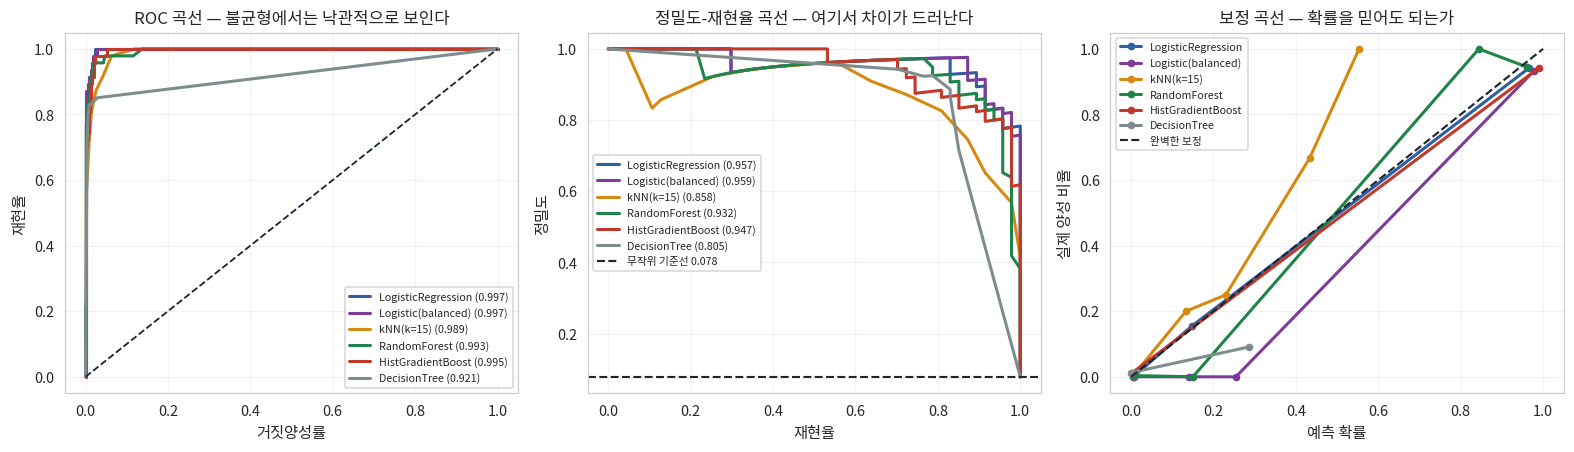

In [ ]:
# ============================================================
# 4-2. ROC · PR · 보정 곡선
# ============================================================
sel = ["LogisticRegression", "Logistic(balanced)", "kNN(k=15)",
       "RandomForest", "HistGradientBoost", "DecisionTree"]
pal = {n: c for n, c in zip(sel, [C["blue"], C["purple"], C["amber"],
                                  C["green"], C["red"], C["gray"]])}

fig, axes = panel(1, 3, w=4.8, h=4.2)

for n in sel:
    fpr, tpr, _ = roc_curve(yc_te, probs[n])
    axes[0].plot(fpr, tpr, lw=2, color=pal[n], label=f"{n} ({roc_auc_score(yc_te, probs[n]):.3f})")
axes[0].plot([0, 1], [0, 1], color=C["dark"], ls="--", lw=1.2)
axes[0].set_xlabel("거짓양성률"); axes[0].set_ylabel("재현율")
axes[0].set_title("ROC 곡선 — 불균형에서는 낙관적으로 보인다")
axes[0].legend(fontsize=7)

for n in sel:
    pr, rc, _ = precision_recall_curve(yc_te, probs[n])
    axes[1].plot(rc, pr, lw=2, color=pal[n],
                 label=f"{n} ({average_precision_score(yc_te, probs[n]):.3f})")
axes[1].axhline(yc_te.mean(), color=C["dark"], ls="--", lw=1.4,
                label=f"무작위 기준선 {yc_te.mean():.3f}")
axes[1].set_xlabel("재현율"); axes[1].set_ylabel("정밀도")
axes[1].set_title("정밀도-재현율 곡선 — 여기서 차이가 드러난다")
axes[1].legend(fontsize=7)

# 보정 곡선 (직접 계산)
for n in sel:
    p = np.clip(probs[n], 0, 1)
    bins = np.linspace(0, 1, 11)
    idx = np.digitize(p, bins) - 1
    xs_, ys_ = [], []
    for b in range(10):
        m_ = idx == b
        if m_.sum() >= 10:
            xs_.append(p[m_].mean()); ys_.append(yc_te.to_numpy()[m_].mean())
    axes[2].plot(xs_, ys_, "o-", lw=2, ms=4, color=pal[n], label=n)
axes[2].plot([0, 1], [0, 1], color=C["dark"], ls="--", lw=1.4, label="완벽한 보정")
axes[2].set_xlabel("예측 확률"); axes[2].set_ylabel("실제 양성 비율")
axes[2].set_title("보정 곡선 — 확률을 믿어도 되는가")
axes[2].legend(fontsize=7)

fig.tight_layout(); plt.show()

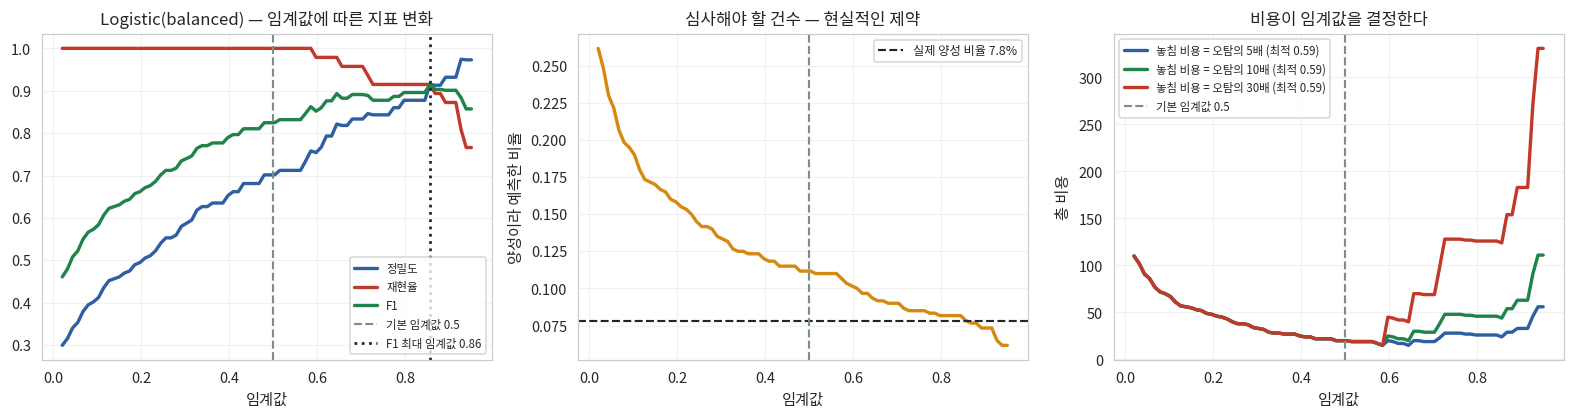

Precision@k — 상위 k건을 심사했을 때의 적중률
--------------------------------------------
                모델  Precision@20  Precision@50  Precision@100  Precision@200
LogisticRegression         0.950         0.860          0.470          0.235
Logistic(balanced)         0.950         0.860          0.470          0.235
         kNN(k=15)         0.950         0.760          0.460          0.235
      RandomForest         0.950         0.860          0.460          0.235
 HistGradientBoost         1.000         0.840          0.470          0.235
      DecisionTree         0.900         0.780          0.420          0.215

무작위로 골랐을 때의 기대 적중률 = 0.078


In [ ]:
# ============================================================
# 4-3. 임계값을 바꾸면 무엇이 달라지는가
# ============================================================
best = cls_board.iloc[0]["모델"]
p_best = np.clip(probs[best], 0, 1)
ths = np.linspace(0.02, 0.95, 80)

prec, rec, f1s, alerts = [], [], [], []
for t in ths:
    pred = (p_best >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(yc_te, pred, labels=[0, 1]).ravel()
    prec.append(tp / max(tp + fp, 1))
    rec.append(tp / max(tp + fn, 1))
    f1s.append(2 * tp / max(2 * tp + fp + fn, 1))
    alerts.append((tp + fp) / len(yc_te))

fig, axes = panel(1, 3, w=4.8, h=3.9)
axes[0].plot(ths, prec, lw=2.2, color=C["blue"], label="정밀도")
axes[0].plot(ths, rec, lw=2.2, color=C["red"], label="재현율")
axes[0].plot(ths, f1s, lw=2.2, color=C["green"], label="F1")
bt = ths[int(np.argmax(f1s))]
axes[0].axvline(0.5, color=C["gray"], ls="--", lw=1.4, label="기본 임계값 0.5")
axes[0].axvline(bt, color=C["dark"], ls=":", lw=1.8, label=f"F1 최대 임계값 {bt:.2f}")
axes[0].set_xlabel("임계값"); axes[0].set_title(f"{best} — 임계값에 따른 지표 변화")
axes[0].legend(fontsize=7.5)

axes[1].plot(ths, alerts, lw=2.2, color=C["amber"])
axes[1].axhline(yc_te.mean(), color=C["dark"], ls="--", lw=1.4,
                label=f"실제 양성 비율 {yc_te.mean():.1%}")
axes[1].axvline(0.5, color=C["gray"], ls="--", lw=1.4)
axes[1].set_xlabel("임계값"); axes[1].set_ylabel("양성이라 예측한 비율")
axes[1].set_title("심사해야 할 건수 — 현실적인 제약")
axes[1].legend(fontsize=8)

# 비용 기반 최적 임계값
for c_fn, col in [(5, C["blue"]), (10, C["green"]), (30, C["red"])]:
    costs = []
    for t in ths:
        pred = (p_best >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(yc_te, pred, labels=[0, 1]).ravel()
        costs.append(fp * 1 + fn * c_fn)
    costs = np.array(costs)
    axes[2].plot(ths, costs, lw=2.2, color=col,
                 label=f"놓침 비용 = 오탐의 {c_fn}배 (최적 {ths[int(np.argmin(costs))]:.2f})")
axes[2].axvline(0.5, color=C["gray"], ls="--", lw=1.4, label="기본 임계값 0.5")
axes[2].set_xlabel("임계값"); axes[2].set_ylabel("총 비용")
axes[2].set_title("비용이 임계값을 결정한다")
axes[2].legend(fontsize=7.5)
fig.tight_layout(); plt.show()

k_list = [20, 50, 100, 200]
rows = []
for n in sel:
    p = probs[n]
    order = np.argsort(-p)
    row = {"모델": n}
    for k in k_list:
        row[f"Precision@{k}"] = float(yc_te.to_numpy()[order[:k]].mean())
    rows.append(row)
show_table(pd.DataFrame(rows), "Precision@k — 상위 k건을 심사했을 때의 적중률", "{:.3f}")
print(f"무작위로 골랐을 때의 기대 적중률 = {yc_te.mean():.3f}")

### 분류에서 짚어야 할 세 가지

ROC와 PR의 차이가 그림으로 확인됩니다. ROC 곡선에서는 모든 모델이 왼쪽 위 구석에 붙어서 다 잘하는 것처럼 보입니다. AUC가 0.97, 0.98 같은 숫자로 나오고요. 그런데 PR 곡선으로 가면 곡선들이 확연히 갈라집니다.

이유는 앞 노트북에서 설명한 대로입니다. ROC의 가로축인 거짓양성률의 분모가 음성 개수인데, 음성이 92%라 분모가 큽니다. 거짓양성이 수십 건 늘어도 곡선이 거의 안 움직이죠. PR 곡선에서는 정밀도의 분모가 양성이라고 예측한 개수라 이 문제가 없습니다.

보정 곡선은 확률을 그대로 써도 되는지 알려 줍니다. 로지스틱 회귀는 대각선에 비교적 잘 붙습니다. 로그손실을 최소화하도록 학습되었으니 확률 자체가 목표였던 거죠.

트리 앙상블은 대각선에서 벗어나는 경향이 있습니다. 랜덤포레스트는 개별 트리의 투표 비율을 확률로 쓰는데, 이 값은 0과 1 쪽으로 잘 안 가는 성질이 있습니다. 모든 트리가 만장일치하기는 어려우니까요. 그래서 실제로는 확실한 경우인데도 0.8 정도만 내놓곤 합니다.

이게 왜 중요하냐면, 확률을 숫자 그대로 쓰는 경우가 많기 때문입니다. 기대 손실을 계산해서 의사결정을 하거나, 예측 확률을 다른 시스템에 넘기거나, 고객에게 "이 거래가 사기일 확률 73%"라고 보여 주거나요. 순위만 필요하면 보정이 안 되어 있어도 상관없지만, 숫자를 쓸 거면 `CalibratedClassifierCV` 같은 걸로 보정해야 합니다.

임계값은 모델이 아니라 비용이 정합니다. 세 번째 그림이 그 이야기입니다.

놓침의 비용이 오탐의 5배일 때와 30배일 때 최적 임계값이 완전히 다릅니다. 놓치는 게 치명적이면 임계값을 낮춰서 많이 잡아야 하고, 오탐 처리 비용이 크면 높여야 합니다. 0.5는 그냥 기본값일 뿐 어떤 의미도 없습니다.

두 번째 그림도 실무에서 자주 쓰는 관점입니다. 심사 인력이 하루에 100건밖에 못 본다면 임계값을 성능이 아니라 처리 용량에 맞춰야 하니까요. 그럴 때 보는 지표가 Precision@k입니다. 표를 보시면 상위 20건의 적중률이 무작위 기준선보다 훨씬 높게 나옵니다. 이 숫자가 "모델을 도입하면 심사 효율이 몇 배 올라간다"는 말로 바로 번역됩니다.

---

# 5부. 정리와 선택 가이드

## 5-1. 실험에서 얻은 결론

비교는 공정해야 의미가 있습니다. 1-2절에서 분할 시드만 바꿔도 RMSE가 꽤 흔들린다는 것을 봤습니다. 한 번의 홀드아웃으로 모델을 고르면 분할 운을 고르는 셈이 됩니다. 교차검증으로 여러 fold의 점수를 얻고, 평균과 함께 표준편차를 보고, 모델 간 비교는 같은 fold 안에서 짝지어 해야 합니다.

진단이 성능 숫자보다 많은 것을 말합니다. 잔차의 표준편차가 진짜 $\sigma$ 에 맞아떨어지면 더 할 것이 없다는 신호입니다. 학습곡선의 간격이 크면 데이터를 더 모으는 것이 효과가 있고, 두 곡선이 높은 곳에서 만나면 모델이나 특성을 바꿔야 합니다. 검증곡선의 U자 바닥이 최적 복잡도고요.

전처리 민감도는 모델마다 다릅니다. 스케일링은 거리 기반 모델과 정규화된 선형 모델에만 필요하고 트리 계열에는 무의미합니다. 이상치는 방향에 따라 다른데, y 방향은 로버스트 손실이 잘 막고 x 방향 지렛대점은 트리 계열이 잘 버팁니다. 결측에는 모든 모델이 약하지만 HistGradientBoosting의 네이티브 처리가 대치보다 낫습니다.

순위는 데이터 구조에 달려 있습니다. 3-5절에서 데이터만 비선형으로 바꿨더니 순위가 뒤집혔습니다. 어떤 모델이 항상 낫다는 말은 성립하지 않습니다.

분류에서는 임계값이 모델만큼 중요합니다. 같은 모델이라도 임계값을 바꾸면 정밀도와 재현율이 완전히 달라집니다. 그리고 그 선택의 근거는 성능 지표가 아니라 오탐과 놓침의 비용입니다.

## 5-2. 모델 선택 가이드

먼저 기준선을 세우세요. `DummyRegressor`나 `DummyClassifier`, 그리고 정규화된 선형 모델 하나. 이 둘이면 "이 문제가 얼마나 어려운가"에 대한 감이 잡힙니다. 선형 모델이 기준선을 크게 못 이기면 특성 쪽에 문제가 있는 겁니다. 모델을 바꿀 때가 아니라 데이터를 다시 볼 때고요.

계수 해석이 필요하면 선형 계열로 갑니다. 규제 산업이나 의사결정 근거를 설명해야 하는 상황이면 선택의 여지가 별로 없습니다. 다만 이상치에 약하니 로버스트 버전을 함께 검토하세요.

성능이 우선이고 표 형태 데이터라면 부스팅 계열이 대체로 강합니다. 비선형과 상호작용을 자동으로 잡고, 스케일링이 필요 없고, 결측도 네이티브로 처리합니다. HistGradientBoosting은 히스토그램 기반이라 속도도 빠릅니다.

랜덤포레스트는 튜닝 없이 쓸 수 있다는 것이 장점입니다. 트리 개수만 충분히 늘리면 과적합이 거의 없고 기본값으로도 잘 나옵니다. 빠른 베이스라인으로 좋습니다.

kNN과 SVM은 변수가 적고 표본이 중간 규모일 때 고려합니다. 변수가 많아지면 거리가 의미를 잃고, 표본이 커지면 예측 비용이 감당이 안 됩니다.

데이터 품질이 들쭉날쭉하면 오염 내성을 성능과 함께 봅니다. 3-4절의 히트맵이 그 판단을 돕는 도구입니다. 깨끗할 때 1등인 모델이 운영에서도 1등이라는 보장은 없습니다.

## 5-3. 연습 문제

**1.** 1-3절의 교차검증을 `RepeatedKFold(n_splits=5, n_repeats=5)`로 바꿔 돌려 보세요. fold 점수가 25개가 되면 1-5절의 t검정 결과가 어떻게 달라지는지, 유의한 쌍이 몇 개로 늘어나는지 확인해 보시기 바랍니다.

**2.** 3-1절에서 `dist` 대신 `area`를 1000배로 만들면 어떻게 될까요? 어느 변수를 왜곡하느냐에 따라 피해가 달라지는지, 그렇다면 그 이유가 무엇인지 생각해 보세요.

**3.** 3-3절의 이상치 실험에 `HistGradientBoostingRegressor(loss="absolute_error")`를 추가해 보세요. 부스팅에서 손실 함수를 바꾸는 것이 y 방향 이상치와 x 방향 지렛대점 각각에 어떤 효과를 내는지 비교해 보시기 바랍니다.

**4.** 3-5절의 비선형 데이터에서 선형회귀에 다항 특성을 추가해 보세요. `PolynomialFeatures(degree=2)`를 파이프라인에 넣으면 상호작용항이 생깁니다. 선형 모델이 앙상블을 따라잡을 수 있는지, 그리고 차수를 3, 4로 올리면 어디서 과적합이 시작되는지 확인해 보세요.

**5.** 4부의 랜덤포레스트에 `CalibratedClassifierCV`를 적용해서 보정 곡선이 대각선에 가까워지는지 보세요. Brier 점수가 얼마나 개선되는지, 그리고 PR-AUC는 변하는지 확인해 보시기 바랍니다. 보정이 순위를 바꾸는지 아닌지가 관전 포인트입니다.

---

## 마무리

두 노트북을 이어서 정리하면 이렇습니다.

첫 번째 노트북에서 전처리가 성능을 크게 바꾼다는 것을 확인했습니다. 모델을 고정해 놓고 전처리만 바꿨는데 RMSE가 두 배 이상 벌어졌죠.

이번 노트북에서는 데이터를 고정해 놓고 모델을 바꿨습니다. 그랬더니 깨끗한 데이터에서는 모델 간 차이가 생각보다 크지 않았습니다. 상위 몇 개 모델이 전부 이론 하한 근처에 몰려 있었고요. 그런데 데이터를 오염시키자 격차가 크게 벌어졌습니다.

즉 모델 선택과 전처리는 독립적인 문제가 아닙니다. 어떤 모델을 쓰느냐가 어떤 전처리가 필요한지를 결정하고, 데이터가 얼마나 더러우냐가 어떤 모델이 살아남는지를 결정합니다.

실무에서 흔히 하는 실수가 이 둘을 따로 최적화하는 겁니다. 깨끗한 개발 데이터에서 모델을 고르고, 나중에 운영 데이터가 더러워서 성능이 떨어지면 그때서야 전처리를 손보죠. 3-4절의 히트맵 같은 것을 개발 단계에서 한 번 그려 두면 이런 일을 줄일 수 있습니다.

마지막으로 한 가지. 이 노트북의 모든 숫자는 우리가 만든 합성 데이터에서 나온 것입니다. 여러분의 데이터에서는 다르게 나올 겁니다. 중요한 것은 결론이 아니라 확인하는 방법입니다. 같은 실험을 여러분의 데이터에 돌려 보시고, 그 결과를 근거로 판단하시면 됩니다.